# TURBOFAN MOTORLARINDA ERKEN ARIZA RİSKİ TAHMİNİ

### NASA C-MAPSS FD001  ·  LightGBM  ·  SHAP  ·  Cyclops Android

---

# Çalışmanın Amacı

Motorlardan alınan sensör ölçümlerini kullanarak **arıza riskini erken fark eden**, verdiği uyarının nedenlerini açıklayan ve sonuçları mobil bir karar destek ekranına taşıyan bir sistem geliştirmek.

Bu notebook, ham motor verisinin incelenmesinden model eğitimine, özellik seçimine ve Android uygulamasında kullanılacak JSON dosyalarının hazırlanmasına kadar süreci adım adım belgelemektedir.

---

## Araştırma problemi

Bir motorun tam olarak ne zaman arızalanacağını ekranda biliniyormuş gibi göstermek yerine, eldeki sensör geçmişine göre **kritik kalan ömür bölgesinde olma olasılığını** tahmin ediyoruz:

$$
P\!\left(\mathrm{RUL}\leq 24\;\middle|\;\text{sensör geçmişi}\right)
$$

Burada **RUL** (*Remaining Useful Life*), arızaya kalan kullanım döngüsüdür. **24 döngü**, değerlendirmede kullanılan kritik bölge sınırıdır; örneğin `RUL = 18` riskli sınıfa, `RUL = 40` güvenli sınıfa girer.

| **Çalışmanın bileşeni** | **Bu projedeki karşılığı** |
|:---|:---|
| **Girdi** | Motorun operasyon ayarları, sensör değerleri ve bunlardan türetilen zamansal özellikler |
| **Tahmin hedefi** | `RUL ≤ 24` koşulunun olasılığı |
| **Öğrenme yöntemi** | LightGBM ile ikili sınıflandırma |
| **Kararın açıklaması** | SHAP ile tahmine katkı veren özelliklerin incelenmesi |
| **Kullanıcıya sunum** | Motor bazlı JSON çıktıları ve Cyclops Android arayüzü |

---

## Veri seti: C-MAPSS FD001

NASA'nın yayımladığı **C-MAPSS**, turbofan motorlarının zaman içindeki bozulmasını simüle eden bir veri setidir. Buradaki kayıtlar gerçek bir havayolu filosundan değil, simülasyondan gelmektedir; bu nedenle çalışmanın sonucu **gerçek bakım kararı değil, bir karar destek prototipidir**.

Her satır, belirli bir motorun belirli bir kullanım döngüsünde kaydedilmiş ölçümlerini temsil eder. Aynı motora ait satırlar bir araya geldiğinde motorun zaman içindeki değişimi görülebilir.

| **Veri alanı** | **Anlamı** | **Bu çalışmada neden önemli?** |
|:---|:---|:---|
| `unit` | Motor kimliği | Farklı motorların kayıtlarını birbirinden ayırır. |
| `cycle` | Kullanım/uçuş döngüsü | Ölçümlerin hangi sırayla alındığını gösterir. |
| `set1`–`set3` | Operasyon ayarları | Ölçümün alındığı çalışma koşullarını tanımlar. |
| `s1`–`s21` | Sensör ölçümleri | Motor durumundaki değişimlere ilişkin ham veriyi sağlar. |
| `RUL` | Arızaya kalan döngü | Eğitim ve değerlendirmede kullanılacak hedefin temelidir. |

### Eğitim ve test neden farklı?

| **Bölüm** | **Motor** | **Kayıt** | **Kayıtların sonu** |
|:---|---:|---:|:---|
| **Eğitim** | 100 | 20.631 | Motorlar arızaya kadar izlenir. |
| **Test** | 100 | 13.096 | Motorların kayıtları arızadan önce kesilir. |

Test motorlarının kesinti anında kalan gerçek ömürleri `RUL_FD001.txt` dosyasında ayrıca verilir. Bu ayrım önemlidir: eğitimde son arıza anı görülebilirken testte model, henüz tamamlanmamış bir motor geçmişi üzerinden değerlendirilir.

---

## Çalışmanın yol haritası

| **Aşama** | **Yanıtladığı soru** | **Çıktı** |
|:---:|:---|:---|
| **01 · Veri inceleme** | Hangi motor, döngü ve sensörler var? | Düzenlenmiş veri ve ilk gözlemler |
| **02 · RUL hesabı** | Arızaya kaç kullanım kaldı? | Motor/döngü bazında kalan ömür |
| **03 · Özellik üretimi** | Sensörler zaman içinde nasıl değişiyor? | Hareketli ortalama, gecikme ve eğim özellikleri |
| **04 · Modelleme** | Riskli durumu ayırt edebilir miyiz? | LightGBM risk skorları |
| **05 · Açıklama** | Hangi özellikler tahmini etkiliyor? | SHAP katkıları ve seçilmiş özellikler |
| **06 · Mobil aktarım** | Sonuçları cihazda nasıl göstereceğiz? | Android uygulamasının okuyacağı JSON dosyaları |

---

### Kapsam notu

**FD001 üzerinde elde edilen sonuçlar, gerçek motorlarda doğrulanmış bir bakım sistemi iddiası taşımaz.** Bu notebook, modelleme yaklaşımının ve mobil karar destek gösteriminin nasıl geliştirildiğini açık ve tekrar incelenebilir biçimde sunar.

In [1]:
import pandas as pd
import os

data_dir = '/kaggle/input/datasets/behrad3d/nasa-cmaps/CMaps/'

# Başlık (header) olmadığını varsayıp doğrudan okuyoruz
train_df = pd.read_csv(os.path.join(data_dir, 'train_FD001.txt'), sep=r'\s+', header=None)

print(f"Tablo boyutu: {train_df.shape}")
display(train_df.head())

Tablo boyutu: (20631, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [2]:
# Kolon neyin nesi artık biliyoruz, isimleri atayalım.

cols = ['unit', 'cycle', 'set1', 'set2', 'set3'] + [f's{i}' for i in range(1, 22)]
train_df.columns = cols

# Şimdi tabloya tekrar bakalım
display(train_df.head())

,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# Test verisini belirlediğimiz kolon isimleriyle okuyoruz
test_df = pd.read_csv(os.path.join(data_dir, 'test_FD001.txt'), sep=r'\s+', header=None, names=cols)

# Test motorlarının gerçekte kalan ömürleri (Sadece tek bir kolon)
rul = pd.read_csv(os.path.join(data_dir, 'RUL_FD001.txt'), sep=r'\s+', header=None, names=['RUL'])

print(f"Test boyutu: {test_df.shape} | Test motor sayısı: {test_df['unit'].nunique()}")
print(f"RUL boyutu: {rul.shape}")

# Test setine ufak bir bakış
display(test_df.head())

Test boyutu: (13096, 26) | Test motor sayısı: 100
RUL boyutu: (100, 1)


,unit,cycle,set1,set2,set3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [4]:
# Veri tipleri ve bellek kullanımı
train_df.info()

print("-" * 40)
# Toplam eksik değer sayısına bakalım
toplam_eksik = train_df.isnull().sum().sum()
print(f"Veri setindeki toplam eksik değer (NaN) sayısı: {toplam_eksik}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   set1    20631 non-null  float64
 3   set2    20631 non-null  float64
 4   set3    20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int64  
 22

In [5]:
# Tüm sayısal değişkenlerin istatistiksel özeti
# round(3) ile virgülden sonra 3 basamak alıp göz yormasını engelliyoruz
display(train_df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.507,29.228,1.000,26.000,52.000,77.000,100.000
cycle,20631.0,108.808,68.881,1.000,52.000,104.000,156.000,362.000
set1,20631.0,-0.000,0.002,-0.009,-0.002,0.000,0.002,0.009
set2,20631.0,0.000,0.000,-0.001,-0.000,0.000,0.000,0.001
set3,20631.0,100.000,0.000,100.000,100.000,100.000,100.000,100.000
s1,20631.0,518.670,0.000,518.670,518.670,518.670,518.670,518.670
s2,20631.0,642.681,0.500,641.210,642.325,642.640,643.000,644.530
s3,20631.0,1590.523,6.131,1571.040,1586.260,1590.100,1594.380,1616.910
s4,20631.0,1408.934,9.001,1382.250,1402.360,1408.040,1414.555,1441.490
s5,20631.0,14.620,0.000,14.620,14.620,14.620,14.620,14.620


In [6]:
# Standart sapması 0 olan ve bize hiçbir şey katmayan kolonları veri setinden atıyoruz
drop_cols = ['set3', 's1', 's5', 's10', 's16', 's18', 's19']

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

print(f"Temizlik sonrası kolon sayımız: {train_df.shape[1]}")

Temizlik sonrası kolon sayımız: 19


In [7]:
# Her motorun maksimum yaşadığı döngüyü (cycle) bulalım (Bozulma anı)
max_cycles = train_df.groupby('unit')['cycle'].max().reset_index()
max_cycles.rename(columns={'cycle': 'max_cycle'}, inplace=True)

# Bunu ana train tablomuza birleştirelim
train_df = train_df.merge(max_cycles, on='unit', how='left')

# Kalan ömür = Maksimum ömür - Şu anki döngü
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

# Artık max_cycle kolonuna ihtiyacımız yok
train_df.drop(columns=['max_cycle'], inplace=True)

# İlk motora bakalım, RUL nasıl azalıyor?
display(train_df[['unit', 'cycle', 'RUL']].head(10))

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


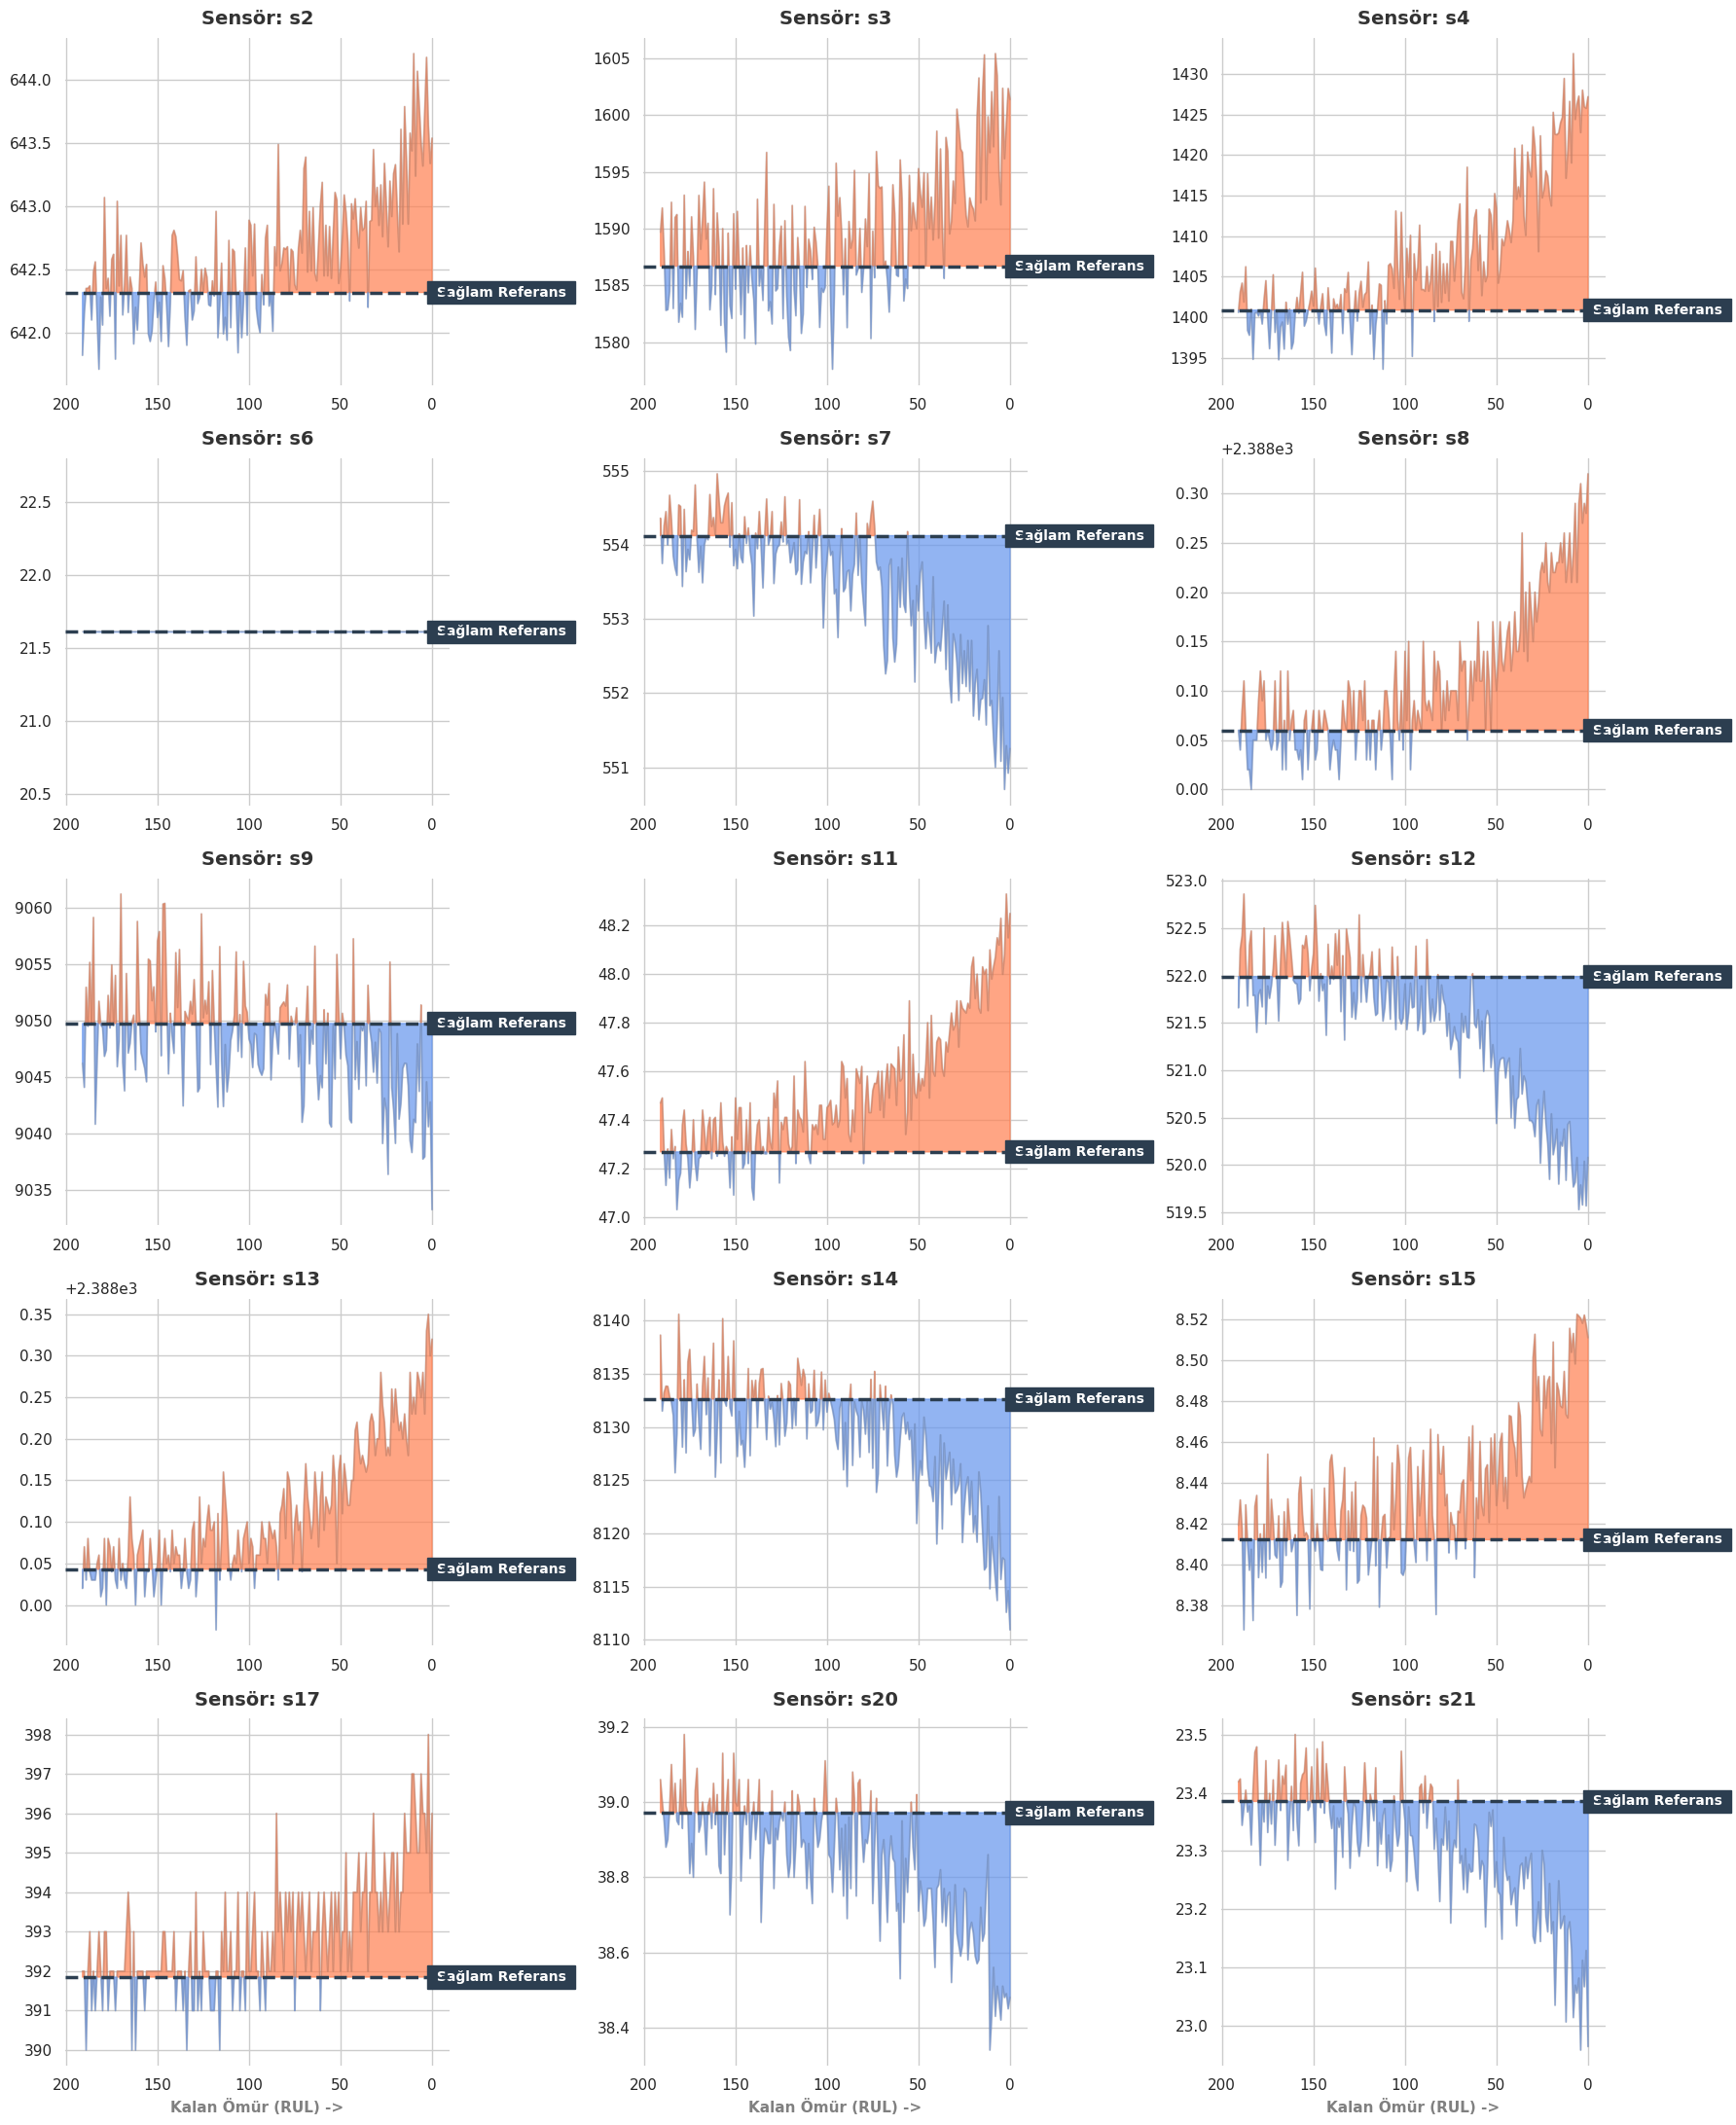

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Değişkenin kaybolmasına karşı tanımı doğrudan buraya alıyoruz
sensor_cols = [col for col in train_df.columns if col.startswith('s') and 'set' not in col]

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

unit1 = train_df[train_df['unit'] == 1]

color_above = '#FF7F50' 
color_below = '#6495ED' 
color_line = '#2C3E50'  

for i, col in enumerate(sensor_cols):
    ax = axes[i]
    
    x = unit1['RUL']
    y = unit1[col]
    
    # Motorun yeni/sağlam olduğu ilk 20 döngünün ortalamasını al (Sağlam Referans)
    healthy_baseline = unit1[unit1['cycle'] <= 20][col].mean()
    
    ax.plot(x, y, color='gray', alpha=0.3, linewidth=1.5)
    
    ax.axhline(healthy_baseline, color=color_line, linestyle='--', linewidth=2.5, zorder=5)
    
    ax.text(0, healthy_baseline, ' Sağlam Referans ', color='white', 
            backgroundcolor=color_line, fontsize=10, 
            va='center', ha='left', weight='bold')
    
    ax.fill_between(x, y, healthy_baseline, where=(y > healthy_baseline), color=color_above, alpha=0.7, interpolate=True)
    ax.fill_between(x, y, healthy_baseline, where=(y <= healthy_baseline), color=color_below, alpha=0.7, interpolate=True)
    
    ax.invert_xaxis()
    
    ax.set_title(f'Sensör: {col}', fontsize=14, fontweight='bold', color='#333333', pad=10)
    
    if i >= 12:
        ax.set_xlabel('Kalan Ömür (RUL) ->', fontsize=11, fontweight='bold', color='gray')
    else:
        ax.set_xlabel('')
        
    sns.despine(ax=ax, left=True, bottom=True)

plt.tight_layout()
plt.show()

# 01 · VERİYİ TANIMA VE HAZIRLAMA

### İlk sekiz hücrenin bulguları  ·  C-MAPSS FD001

---

## Bu aşamada ne yaptık?

Model kurmadan önce verinin yapısını ve hedef değişkeni inceledik. Eğitim ve test dosyalarını okuyup sütunları adlandırdık; eksik değerleri kontrol ettik, değişmeyen sütunları çıkardık ve her motorun **kalan kullanım ömrünü (RUL)** hesapladık. Ardından ilk motorun sensör ölçümlerini sağlıklı dönemindeki değerleriyle karşılaştırarak veriyi görsel olarak inceledik.

| **Adım** | **Yapılan işlem** | **Elde edilen sonuç** |
|:---:|:---|:---|
| **01 · Veriyi yükleme** | Eğitim, test ve test motorlarına ait RUL dosyaları okundu. | `unit`, `cycle`, çalışma ayarları ve sensör alanları ayrıştırıldı. |
| **02 · Kalite kontrolü** | Eksik değerler ve sütunların dağılımı incelendi. | Eğitim verisinde eksik değer görülmedi. |
| **03 · Sütun temizliği** | Sabit kalan bir ayar ve altı sensör sütunu çıkarıldı. | Sütun sayısı **26'dan 19'a** düştü. |
| **04 · RUL hesabı** | Her motorun döngü geçmişine göre kalan ömür hesaplandı. | İlk motorun ilk döngüsünde **RUL = 191** elde edildi. |
| **05 · Görsel inceleme** | İlk motorun sensörleri sağlıklı dönem referansıyla çizildi. | Sensörlerin farklı değişim biçimleri olduğu görüldü. |

---

## Neden sabit sütunları çıkardık?

Bir sütun bütün satırlarda aynı değeri taşıyorsa motorların sağlıklı ve bozulmaya yaklaşan durumları arasında ayrım yapmaya yardımcı olmaz. İnceleme sonucunda `set3`, `s1`, `s5`, `s10`, `s16`, `s18` ve `s19` sütunları çıkarıldı: **bir operasyon ayarı ve altı sensör sütunu**. Bu adım, sonraki özellik üretiminde aynı sabit bilgiden gereksiz yeni sütunlar türetilmesini de önler.

| **Başlangıç** | **Çıkarılan** | **Kalan** |
|:---:|:---:|:---:|
| 26 sütun | 7 sütun | **19 sütun** |

---

## RUL hesabı: Eğitim ve test

RUL (*Remaining Useful Life*), bir motorun arızaya kalan döngü sayısıdır. İki veri bölümünde kayıtların bittiği nokta farklı olduğu için aynı hesap yöntemi doğrudan kullanılamaz.

| **Veri bölümü** | **Arıza anı kayıtta var mı?** | **Hesaplama yaklaşımı** |
|:---|:---:|:---|
| **Eğitim** | Evet | Motorun ulaştığı son döngüden mevcut döngü çıkarılır. |
| **Test** | Hayır | Kayıt sonundaki döngüye referans dosyasındaki kalan ömür eklenir; mevcut döngü çıkarılır. |

**Eğitim verisi**

$$
\mathrm{RUL}_{\mathrm{train}} = \text{motorun son döngüsü} - \text{mevcut döngü}
$$

Bu tanım gereği, motorun son kayıtlı döngüsünde RUL sıfırdır. İlk motorun ilk döngüsünde bulunan **191** değeri, hesaplamanın başlangıç örneğidir.

**Test verisi**

$$
\mathrm{RUL}_{\mathrm{test}} = \text{kaydın son döngüsü} + \text{referans kalan ömür} - \text{mevcut döngü}
$$

Test motorlarının kayıtları arızadan önce sonlandığı için, `RUL_FD001.txt` dosyasındaki değerler olmadan gerçek kalan ömür hesaplanamaz. Bu dosya, her test motoruna ait **kayıt bitimindeki** kalan ömrü sağlar.

---

## Sensör grafiklerinden ne öğrendik?

İlk motorun sensör ölçümleri, motorun ilk 20 döngüsünün ortalaması alınarak oluşturulan **sağlıklı dönem referansı** ile karşılaştırıldı. Böylece tek bir ölçüm yerine sensörün ömür boyunca referanstan nasıl uzaklaştığı incelenebildi.

> **Gözlem**  
> Sensörler aynı davranışı göstermiyor: bazıları motorun ömrü boyunca daha belirgin bir eğilim sergilerken bazıları daha durağan kalıyor. Ham ölçümlerde döngüden döngüye dalgalanmalar da var. Bu grafikler tek başına bir sensörün arızayı kesin olarak açıkladığını kanıtlamaz; hangi değişimlerin model için faydalı olduğunu sonraki aşamalarda sınayacağız.

## Buradan sonra

Bir sonraki bölümde anlık sensör değerlerinin yanına **zamansal özellikler** ekleyeceğiz. Hareketli ortalama ve standart sapma kısa ve uzun dönem davranışını; gecikme geçmiş ölçümleri; eğim ise değişimin yönünü ve hızını temsil edecek. Böylece model yalnızca sensörün bugünkü değerine değil, **nasıl değiştiğine** de bakabilecek.

In [9]:
# Yeni ve geniş zaman pencerelerimiz
ROLL_WINDOWS = [1, 2, 3, 4, 5, 6, 9, 12, 15, 18, 21, 24, 27, 30, 35, 40, 45, 50]

# Orjinal veri setini bozmamak için kopyasını alalım ve sıralayalım
df_fe = train_df.copy()
df_fe = df_fe.sort_values(['unit', 'cycle']).reset_index(drop=True)

# Yeni kolonları biriktireceğimiz boş bir sözlük (dictionary) açıyoruz
new_features = {}

for col in sensor_cols:
    g = df_fe.groupby('unit')[col]
    
    for w in ROLL_WINDOWS:
        # Tek tek DataFrame'e yazmak yerine sözlüğe kaydediyoruz
        new_features[f'{col}_roll_mean_{w}'] = g.transform(lambda x: x.rolling(w, min_periods=1).mean())
        new_features[f'{col}_roll_std_{w}']  = g.transform(lambda x: x.rolling(w, min_periods=1).std())

# Bütün özellikler hesaplandıktan sonra sözlüğü DataFrame'e çevir
new_features_df = pd.DataFrame(new_features)

# Ve tek bir hamlede (axis=1 yani yan yana) ana verimizle birleştir (concat)
df_fe = pd.concat([df_fe, new_features_df], axis=1)

# Standart sapmada oluşan (özellikle ilk satırlardaki) NaN'ları temizleyelim
df_fe.fillna(0, inplace=True)

print(f"İşlem tamam! Hiçbir uyarı almadık.")
print(f"Orijinal kolon sayısı: {train_df.shape[1]}")
print(f"Yeni kolon sayısı: {df_fe.shape[1]}")

İşlem tamam! Hiçbir uyarı almadık.
Orijinal kolon sayısı: 20
Yeni kolon sayısı: 560


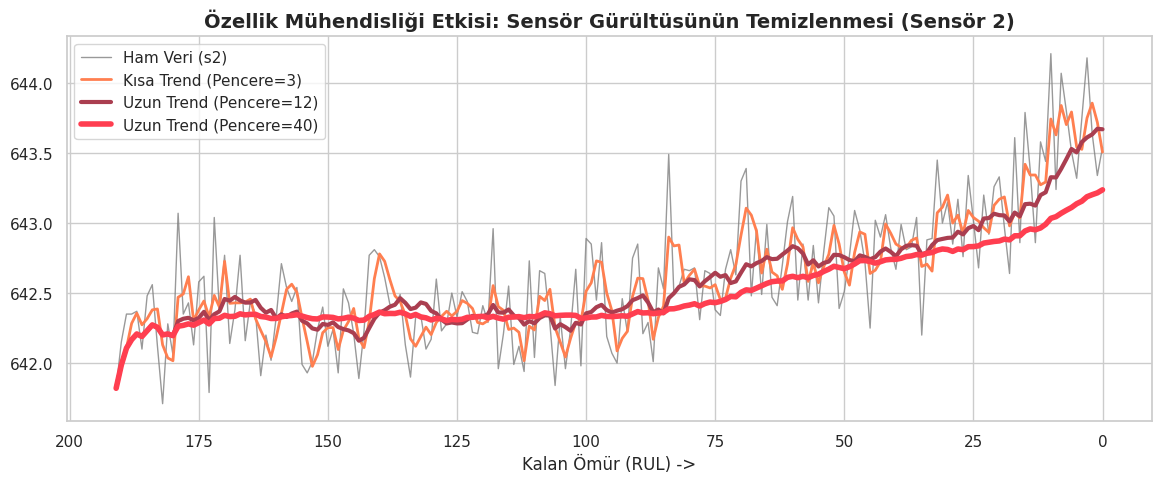

In [10]:
# HÜCRE 2: GÜRÜLTÜYÜ NASIL TEMİZLEDİK? (GÖRSELLEŞTİRME)
plt.figure(figsize=(14, 5))

# Yine 1. motorun, sadece tek bir sensörüne (s2) odaklanalım
unit1_fe = df_fe[df_fe['unit'] == 1]

# Ham sensör verisi (Çok gürültülü ve zikzaklı)
plt.plot(unit1_fe['RUL'], unit1_fe['s2'], 
         label='Ham Veri (s2)', color='gray', alpha=0.8, linewidth=1)

# Kısa dönem trend (6 döngülük yumuşatma)
plt.plot(unit1_fe['RUL'], unit1_fe['s2_roll_mean_3'], 
         label='Kısa Trend (Pencere=3)', color='#FF7F50', linewidth=2)

# Uzun dönem trend (24 döngülük yumuşatma - Model ana bozulmayı buradan çok rahat anlar)
plt.plot(unit1_fe['RUL'], unit1_fe['s2_roll_mean_12'], 
         label='Uzun Trend (Pencere=12)', color='#AA3E50', linewidth=3)

plt.plot(unit1_fe['RUL'], unit1_fe['s2_roll_mean_40'], 
         label='Uzun Trend (Pencere=40)', color='#ff3E50', linewidth=4)

plt.gca().invert_xaxis()
plt.title('Özellik Mühendisliği Etkisi: Sensör Gürültüsünün Temizlenmesi (Sensör 2)', fontsize=14, fontweight='bold')
plt.xlabel('Kalan Ömür (RUL) ->')
plt.legend()
plt.show()

In [11]:
import numpy as np

def fast_rolling_slope(series, window):
    # Eğer yanlışlıkla window 2'den küçük gelirse, hatayı engellemek için direkt 0 dön
    if window < 2:
        return pd.Series(0, index=series.index)
        
    n = window
    x = np.arange(n, dtype=float)
    sum_x, sum_x2 = x.sum(), (x ** 2).sum()
    denom = n * sum_x2 - sum_x ** 2
    y = series.values.astype(float)
    sum_y = series.rolling(n, min_periods=n).sum().values
    kernel = x[::-1]
    sum_xy_full = np.convolve(np.nan_to_num(y), kernel, mode='full')
    sum_xy = np.full(len(y), np.nan)
    sum_xy[n - 1:] = sum_xy_full[n - 1: len(y)]
    slope = (n * sum_xy - sum_x * sum_y) / denom
    return pd.Series(slope, index=series.index)

# NaN oranını dengede tutmak için maksimum 30'a kadar çıkıyoruz.
# Eğim (Slope) listesinden 1 ve 2'yi çıkartıyoruz!
LAG_CYCLES = [1, 2, 3, 4, 5, 6, 9, 12, 15, 18, 21, 24, 30]
SLOPE_WINDOWS = [3, 4, 5, 6, 9, 12, 15, 18, 21, 24, 30]

new_features_step2 = {}

for col in sensor_cols:
    g = df_fe.groupby('unit')[col]
    
    # 1. Gecikmeler
    for lag in LAG_CYCLES:
        new_features_step2[f'{col}_lag_{lag}'] = g.shift(lag)
        
    # 2. Eğimler
    for w in SLOPE_WINDOWS:
        new_features_step2[f'{col}_slope_{w}'] = g.transform(lambda x: fast_rolling_slope(x, w))

# Ana tabloyla birleştir
df_fe = pd.concat([df_fe, pd.DataFrame(new_features_step2)], axis=1)

# Etkileşim özellikleri
df_fe['s2_x_s3'] = df_fe['s2'] * df_fe['s3']
df_fe['s4_div_s11'] = df_fe['s4'] / (df_fe['s11'] + 1e-3)

df_fe['sensor_magnitude'] = np.sqrt(
    df_fe['s2']**2 + df_fe['s3']**2 + df_fe['s4']**2 + 
    df_fe['s7']**2 + df_fe['s11']**2 + df_fe['s12']**2 + df_fe['s15']**2
)

# Kalan tüm NaN ve sonsuzlukları temizle
df_fe.fillna(0, inplace=True)
df_fe.replace([np.inf, -np.inf], 0, inplace=True)

print(f"Gecikme ve Eğim özellikleri hatasız eklendi!")
print(f"Güncel kolon sayımız: {df_fe.shape[1]}")

Gecikme ve Eğim özellikleri hatasız eklendi!
Güncel kolon sayımız: 923


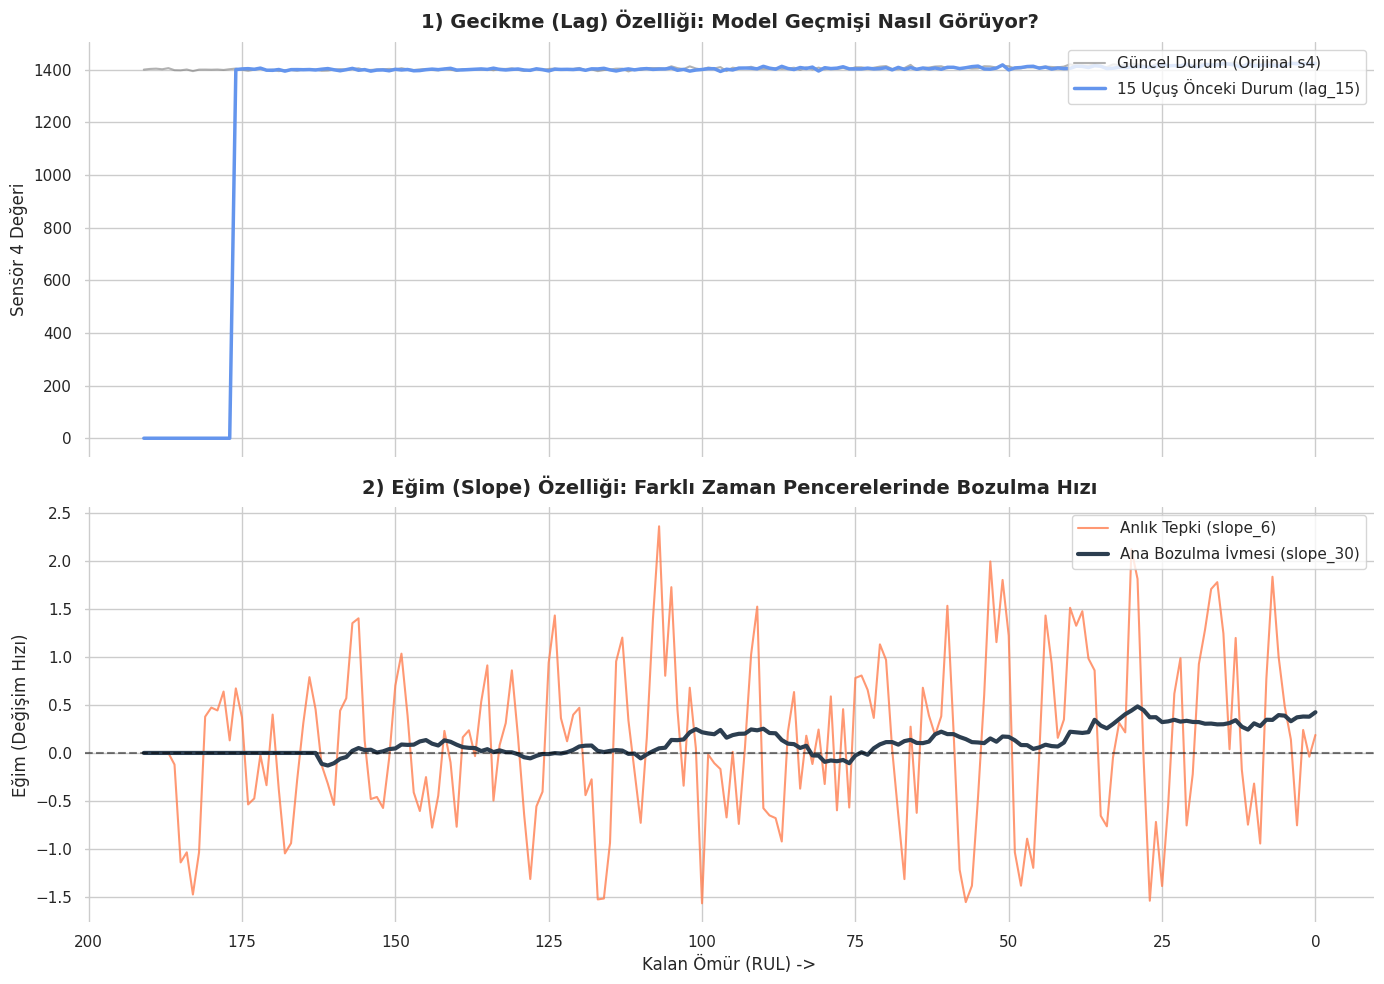

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

unit1_fe = df_fe[df_fe['unit'] == 1]

# ---------------------------------------------------------
# ÜST GRAFİK: Gecikme (Lag) Mantığı
# ---------------------------------------------------------
# Orijinal sensör değeri
ax1.plot(unit1_fe['RUL'], unit1_fe['s4'], 
         label='Güncel Durum (Orijinal s4)', color='gray', alpha=0.6, linewidth=1.5)

# 15 uçuş önceki sensör değeri (Modelin geçmişi hatırlaması)
ax1.plot(unit1_fe['RUL'], unit1_fe['s4_lag_15'], 
         label='15 Uçuş Önceki Durum (lag_15)', color='#6495ED', linewidth=2.5)

ax1.set_title('1) Gecikme (Lag) Özelliği: Model Geçmişi Nasıl Görüyor?', fontsize=14, fontweight='bold', pad=10)
ax1.set_ylabel('Sensör 4 Değeri')
ax1.legend(loc='upper right')

# ---------------------------------------------------------
# ALT GRAFİK: Kısa vs Uzun Vadeli Eğim (Slope)
# ---------------------------------------------------------
# Kısa vadeli ivme (Biraz daha gürültülü, anlık tepkiler)
ax2.plot(unit1_fe['RUL'], unit1_fe['s4_slope_6'], 
         label='Anlık Tepki (slope_6)', color='#FF7F50', alpha=0.8, linewidth=1.5)

# Uzun vadeli ivme (Çok daha temiz, ana bozulma trendi)
ax2.plot(unit1_fe['RUL'], unit1_fe['s4_slope_30'], 
         label='Ana Bozulma İvmesi (slope_30)', color='#2C3E50', linewidth=3)

# 0 (Sıfır İvme / Stabilite) Çizgisi
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)

ax2.set_title('2) Eğim (Slope) Özelliği: Farklı Zaman Pencerelerinde Bozulma Hızı', fontsize=14, fontweight='bold', pad=10)
ax2.set_xlabel('Kalan Ömür (RUL) ->')
ax2.set_ylabel('Eğim (Değişim Hızı)')
ax2.legend(loc='upper right')

# X eksenini ters çevir ve çerçeveleri temizle
ax1.invert_xaxis()
sns.despine(ax=ax1, left=True, bottom=True)
sns.despine(ax=ax2, left=True, bottom=True)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Hızlı eğim fonksiyonumuz (Yukarıda tanımladığımızın aynısı)
def fast_rolling_slope(series, window):
    if window < 2:
        return pd.Series(0, index=series.index)
    n = window
    x = np.arange(n, dtype=float)
    denom = n * (x ** 2).sum() - x.sum() ** 2
    y = series.values.astype(float)
    sum_y = series.rolling(n, min_periods=n).sum().values
    sum_xy_full = np.convolve(np.nan_to_num(y), x[::-1], mode='full')
    sum_xy = np.full(len(y), np.nan)
    sum_xy[n - 1:] = sum_xy_full[n - 1: len(y)]
    return pd.Series((n * sum_xy - x.sum() * sum_y) / denom, index=series.index)

# Tüm özellikleri tek seferde üreten ana fonksiyonumuz
def engineer_features(df, sensor_columns):
    df_fe = df.copy()
    df_fe = df_fe.sort_values(['unit', 'cycle']).reset_index(drop=True)
    
    # Parametrelerimiz (Optimize edilmiş, NaN ve hata üretmeyen versiyonlar)
    ROLL_WINDOWS = [1, 2, 3, 4, 5, 6, 9, 12, 15, 18, 21, 24, 27, 30, 35, 40, 45, 50]
    LAG_CYCLES = [1, 2, 3, 4, 5, 6, 9, 12, 15, 18, 21, 24, 30]
    SLOPE_WINDOWS = [3, 4, 5, 6, 9, 12, 15, 18, 21, 24, 30]
    
    new_features = {}
    
    for col in sensor_columns:
        g = df_fe.groupby('unit')[col]
        
        # 1. Hareketli Ortalamalar ve Std
        for w in ROLL_WINDOWS:
            new_features[f'{col}_roll_mean_{w}'] = g.transform(lambda x: x.rolling(w, min_periods=1).mean())
            new_features[f'{col}_roll_std_{w}']  = g.transform(lambda x: x.rolling(w, min_periods=1).std())
            
        # 2. Gecikmeler (Lag)
        for lag in LAG_CYCLES:
            new_features[f'{col}_lag_{lag}'] = g.shift(lag)
            
        # 3. Eğimler (Slope)
        for w in SLOPE_WINDOWS:
            new_features[f'{col}_slope_{w}'] = g.transform(lambda x: fast_rolling_slope(x, w))
            
        # 4. Anlık Değişim (Fark) -> SENİN KODUNDAN GELEN EKSİK PARÇA
        new_features[f'{col}_diff_1'] = g.diff(1)
    # Hepsini tek seferde tabloya yapıştır
    df_fe = pd.concat([df_fe, pd.DataFrame(new_features)], axis=1)
    
    # Etkileşim özellikleri
    df_fe['s2_x_s3'] = df_fe['s2'] * df_fe['s3']
    df_fe['s4_div_s11'] = df_fe['s4'] / (df_fe['s11'] + 1e-3)
    df_fe['sensor_magnitude'] = np.sqrt(
        df_fe['s2']**2 + df_fe['s3']**2 + df_fe['s4']**2 + 
        df_fe['s7']**2 + df_fe['s11']**2 + df_fe['s12']**2 + df_fe['s15']**2
    )
    
    # NaN ve Sonsuzluk Temizliği
    df_fe.fillna(0, inplace=True)
    df_fe.replace([np.inf, -np.inf], 0, inplace=True)
    
    return df_fe

# Artık hem Train hem Test setimizi tek satırla harika bir hale getirebiliriz!
print("Özellik mühendisliği uygulanıyor... (Biraz sürebilir)")
train_fe = engineer_features(train_df, sensor_cols)
test_fe = engineer_features(test_df, sensor_cols)

print(f"Train Boyutu: {train_fe.shape}")
print(f"Test Boyutu:  {test_fe.shape}")

Özellik mühendisliği uygulanıyor... (Biraz sürebilir)
Train Boyutu: (20631, 938)
Test Boyutu:  (13096, 937)


In [14]:
# Ölçeklenecek kolonları seçelim (unit, cycle ve RUL kolonları hariç hepsi sayısal özellik)
ignore_cols = ['unit', 'cycle', 'RUL']
features = [col for col in train_fe.columns if col not in ignore_cols]

# 0-1 arasına sıkıştırma aracı
scaler = MinMaxScaler()

# Scaler sadece Train'deki minimum ve maksimum değerleri öğrenir
scaler.fit(train_fe[features])

# Öğrendiği kuralları her iki sete de uygular
train_fe[features] = scaler.transform(train_fe[features])
test_fe[features] = scaler.transform(test_fe[features])

print("Tüm özellikler başarıyla 0 ile 1 arasına ölçeklendi (Scaled)!")
display(train_fe[['unit', 'cycle', 'RUL', 's2', 's9', 's2_slope_30']].head())

Tüm özellikler başarıyla 0 ile 1 arasına ölçeklendi (Scaled)!


,unit,cycle,RUL,s2,s9,s2_slope_30
0,1,1,191,0.183735,0.109755,0.370902
1,1,2,190,0.283133,0.100242,0.370902
2,1,3,189,0.343373,0.140043,0.370902
3,1,4,188,0.343373,0.124518,0.370902
4,1,5,187,0.349398,0.149960,0.370902


In [15]:
# 1. PARÇALANMAYI (FRAGMENTATION) TEMİZLEME
# Belleği yeniden yapılandırıp o can sıkıcı PerformanceWarning'i yok ediyoruz
train_fe = train_fe.copy()
test_fe = test_fe.copy()


# 2. TEST SETİ İÇİN RUL (KALAN ÖMÜR) HESAPLAMA
# En başta yüklediğimiz 'rul' tablosunda motor numarası (unit) yoktu, sadece sırayla verilmişti.
# İndeks 0'dan başladığı için 1 ekleyip motor numaralarını oluşturuyoruz.
rul['unit'] = rul.index + 1
rul.rename(columns={'RUL': 'RUL_gercek'}, inplace=True)

# Test setindeki her motorun verisinin "kesildiği" son döngüyü buluyoruz
test_max = test_fe.groupby('unit')['cycle'].max().reset_index()
test_max.rename(columns={'cycle': 'max_test_cycle'}, inplace=True)

# Şimdi bu bilgileri test_fe tablomuza ekleyelim
test_fe = test_fe.merge(test_max, on='unit', how='left')
test_fe = test_fe.merge(rul, on='unit', how='left')

# Test setindeki herhangi bir satırın Kalan Ömrü = 
# (Verinin kesildiği son an + Gerçekte kalan ömür) - O anki uçuş sayısı
test_fe['RUL'] = (test_fe['max_test_cycle'] + test_fe['RUL_gercek']) - test_fe['cycle']

# Kalabalık yapmasın diye aracı kolonları siliyoruz
test_fe.drop(columns=['max_test_cycle', 'RUL_gercek'], inplace=True)


# 3. ERKEN UYARI ETİKETİNİ (LABEL) OLUŞTURMA
HORIZON_CYCLES = 24

train_fe['label'] = (train_fe['RUL'] <= HORIZON_CYCLES).astype(int)
test_fe['label'] = (test_fe['RUL'] <= HORIZON_CYCLES).astype(int)

# Dengesiz veri setini kontrol edelim
train_pozitif_oran = train_fe['label'].mean() * 100
test_pozitif_oran = test_fe['label'].mean() * 100

print(f"Train setindeki 'Tehlikeli (1)' durum oranı: %{train_pozitif_oran:.2f}")
print(f"Test setindeki  'Tehlikeli (1)' durum oranı: %{test_pozitif_oran:.2f}")

# Modelin göreceği (Feature) ve görmeyeceği (Meta) kolonları ayıralım
meta_cols = ['unit', 'cycle', 'RUL', 'label']
feature_cols = [c for c in train_fe.columns if c not in meta_cols]

print(f"\nİşlem başarılı! Model {len(feature_cols)} özellik ile eğitime hazır.")

Train setindeki 'Tehlikeli (1)' durum oranı: %15.03
Test setindeki  'Tehlikeli (1)' durum oranı: %2.54

İşlem başarılı! Model 935 özellik ile eğitime hazır.


# 02 · SENSÖR GEÇMİŞİNDEN RİSK ETİKETİNE

### Hücre 9–15  ·  Zamansal özellikler, ölçekleme ve hedef değişken

---

## Neden yeni özellikler ürettik?

İlk motorun sensör grafiklerinde tek bir döngüdeki ölçümün dalgalanabildiğini gördük. Bu bölümde her sensörün yalnızca **o andaki değerini** değil, son döngülerdeki davranışını da modele aktaracak değişkenler oluşturduk. İşlemler motor bazında ve döngü sırasıyla yapıldı; böylece bir motorun geçmişi başka bir motorun ölçümleriyle karışmadı.

| **Özellik ailesi** | **Nasıl hesaplandı?** | **Ne anlatır?** |
|:---|:---|:---|
| **Hareketli ortalama** | Önceki birkaç döngüdeki ölçümlerin ortalaması | Kısa ve uzun dönem eğilimi |
| **Hareketli standart sapma** | Aynı penceredeki ölçümlerin değişkenliği | Sensörün ne kadar dalgalandığını |
| **Gecikme (lag)** | Önceki döngülerden alınan sensör değeri | Güncel ölçümün geçmişten nasıl ayrıldığını |
| **Eğim (slope)** | Bir zaman penceresindeki doğrusal değişim | Artışın veya azalışın yönünü ve hızını |
| **Anlık fark ve etkileşimler** | Ardışık değer farkı ve seçili sensör birleşimleri | Tek sensörde ya da sensörler arasında oluşan değişimleri |

**Görsel kontrol:** `s2` sensörünün ham çizgisi hareketli ortalamalarla; `s4` sensörünün güncel değeri ise gecikme ve kısa/uzun dönem eğimlerle karşılaştırıldı. Bu grafiklerin amacı performans kanıtlamak değil, üretilen değişkenlerin **ne tür bilgiyi temsil ettiğini** görünür kılmaktır.

---

## Özellik havuzu ve ölçekleme

Eğitim ve test verilerine aynı özellik üretme işlemi uygulandı. Ardından motor kimliği, döngü ve RUL dışındaki sayısal model girdileri `MinMaxScaler` ile ölçeklendi.

| **Aşama** | **Notebook çıktısı** | **Yorum** |
|:---|:---:|:---|
| Eğitimde özellik üretimi | **20.631 × 938** | RUL dâhil, etiket eklenmeden önceki tablo |
| Testte özellik üretimi | **13.096 × 937** | Test RUL değeri bir sonraki adımda ekleniyor. |
| Etiket sonrası model girdisi | **935 özellik** | `unit`, `cycle`, `RUL` ve `label` girdi olarak kullanılmıyor. |

> **Ölçekleme ilkesi**  
> Ölçekleyicinin alt ve üst sınırları yalnızca **eğitim verisinden** öğrenildi; öğrenilen aynı dönüşüm test verisine uygulandı. Böylece test ölçümlerinin dağılımı, eğitim aşamasında ölçekleyiciye önceden verilmedi.

---

## Test motorlarında RUL neden ayrıca hesaplandı?

Eğitim motorlarının son döngüsü arıza noktasıdır; bu nedenle eğitim RUL'u önceki bölümde doğrudan hesaplanabildi. Test motorlarının kayıtları ise arızadan **önce** kesilir. `RUL_FD001.txt`, her test motorunun kesinti anında gerçekte kaç döngü ömrü kaldığını bildirir.

| **Bilgi** | **Kaynağı** | **Hesaptaki rolü** |
|:---|:---|:---|
| Motorun son kayıtlı döngüsü | `test_FD001.txt` | Kayıt kesintisinin konumu |
| Kesinti anında kalan ömür | `RUL_FD001.txt` | Kesintiden sonraki gerçek kalan döngüler |
| Satırın mevcut döngüsü | `test_FD001.txt` | RUL'u ilgili satıra geri taşıma |

$$
\mathrm{RUL}_{\mathrm{test}}
= \text{son kayıtlı döngü}
+ \text{kesinti anındaki kalan ömür}
- \text{mevcut döngü}
$$

Referans dosyasındaki satırlar motor kimlikleriyle eşleştirildikten sonra bu işlem test setinin **her döngüsü** için yapıldı. RUL ve motor kimliği, modelin sensör girdilerine eklenmedi; yalnızca hedefi oluşturmak ve sonuçları değerlendirmek için kullanıldı.

---

## Tahmin hedefi: Riskli mi, güvenli mi?

Bu çalışmada kritik bölge sınırı **24 döngü** olarak belirlendi. RUL'u bu sınırda veya altında olan kayıtlar `1`, diğerleri `0` etiketini aldı:

$$
\mathrm{label}=
\begin{cases}
1, & \mathrm{RUL}\leq 24\\
0, & \mathrm{RUL}>24
\end{cases}
$$

| **Sınıf** | **Koşul** | **Anlamı** |
|:---:|:---:|:---|
| **1 · Riskli** | `RUL ≤ 24` | Motor kritik kalan ömür bölgesindedir. |
| **0 · Güvenli** | `RUL > 24` | Motor bu kritik bölgenin dışındadır. |

Buradaki olasılık, **o anki sensör geçmişine göre RUL'un 24 veya altında olma olasılığıdır**; motorun tam arıza tarihinin kesin tahmini değildir.

---

## Sınıf dağılımı: İlk bulgu

| **Veri** | **Riskli sınıf oranı** | **İlk yorum** |
|:---|---:|:---|
| **Eğitim** | **%15,03** | Motorlar arızaya kadar izlenir; son döngüler de kayıttadır. |
| **Test** | **%2,54** | Kayıtların çoğu kritik bölgeye ulaşmadan kesilmiştir. |

İki veri bölümünde riskli kayıtlar aynı oranda değildir. Bu nedenle sonraki modelleme aşamasında yalnızca toplam doğruluğa bakmak yeterli olmayacak; **riskli sınıfı ne ölçüde yakaladığımızı** da ayrıca değerlendireceğiz. Bu bölümün çıktısı, model eğitimine hazır **935 sensör/operasyon özelliği** ve her satır için risk etiketidir.

### Sıradaki soru

> Bu geniş özellik havuzuyla model riskli döngüleri ayırt edebilecek mi; edebilirse hangi sensör geçmişleri kararında gerçekten etkili olacak?

In [16]:
import numpy as np
import pandas as pd
import warnings

# Gerekli değişkenlerin tanımlı olduğundan emin olalım
SHAP_SAMPLE_N = 500  # SHAP hesaplamasını hızlandırmak için test setinden örneklem boyutu
CUMULATIVE_SHAP_THRESHOLD = 0.95  # %95 Kümülatif önem eşiği

# Train ve Test setlerini matrislere ayıralım
# Not: Önceki adımda feature_cols listesini oluşturmuştuk, burada onu kullanıyoruz
X_train, y_train = train_fe[feature_cols], train_fe['label']
X_test, y_test = test_fe[feature_cols], test_fe['label']

from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import train_test_split

# Dengesiz veri (Imbalanced data) için sınıf ağırlığını otomatik hesaplayalım
spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

# Early stopping için train setinden küçük bir validation dilimi ayırıyoruz
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

clf_full = LGBMClassifier(
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    min_split_gain=0.0,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.5,
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
print("LightGBM modeli (10.000 iterasyon, 100 erken durdurma) kullanılıyor...")

# Modeli early stopping ile eğitiyoruz
clf_full.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=200)]
)

print(f"\nEn iyi iterasyon: {clf_full.best_iteration_}")

# Performansı ölçelim
from sklearn.metrics import roc_auc_score
proba_full = clf_full.predict_proba(X_test)[:, 1]
roc_auc_full = roc_auc_score(y_test, proba_full)
print(f"\n[ARA MODEL - 920 Özellik] Test ROC-AUC Skoru: {roc_auc_full:.4f}")

LightGBM modeli (10.000 iterasyon, 100 erken durdurma) kullanılıyor...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.999318	valid_0's binary_logloss: 0.0635337
[400]	valid_0's auc: 0.999614	valid_0's binary_logloss: 0.0289733
[600]	valid_0's auc: 0.999704	valid_0's binary_logloss: 0.021314
[800]	valid_0's auc: 0.999737	valid_0's binary_logloss: 0.0188446
[1000]	valid_0's auc: 0.999763	valid_0's binary_logloss: 0.0176456
Early stopping, best iteration is:
[1037]	valid_0's auc: 0.99977	valid_0's binary_logloss: 0.0174228

En iyi iterasyon: 1037

[ARA MODEL - 920 Özellik] Test ROC-AUC Skoru: 0.9984


In [17]:
import shap
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ============================================================
# SAĞLAM (ROBUST) SHAP HESABI
# 920 özellik gibi yüksek boyutta tek seferlik küçük örneklem SHAP'ı
# gürültülü ve tekrar üretilemez (non-reproducible) sonuç verir.
# Bunun yerine: daha büyük örneklem + çoklu seed ortalaması alarak
# hem hız/performans dengesini koruyoruz hem de sıralamayı stabilize ediyoruz.
# ============================================================

SHAP_SAMPLE_N = 1500
N_SEEDS = 5
RANDOM_SEEDS = [42, 7, 123, 2024, 99]

sample_size = min(SHAP_SAMPLE_N, len(X_test))
print(f"SHAP değerleri {sample_size} örneklem x {N_SEEDS} seed üzerinden hesaplanıyor (stabilite için)...")

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    # TreeExplainer'ı bir kez kuruyoruz, örneklemi her seed'de değiştiriyoruz
    explainer_tmp = shap.TreeExplainer(
        clf_full,
        feature_perturbation="tree_path_dependent"  # LightGBM için hızlı ve tutarlı yol
    )

    shap_runs = []
    for seed in RANDOM_SEEDS:
        X_sample_run = X_test.sample(sample_size, random_state=seed)
        raw_shap = explainer_tmp.shap_values(X_sample_run)

        if isinstance(raw_shap, list):
            shap_vals_run = np.array(raw_shap[1])
        else:
            raw_shap = np.array(raw_shap)
            shap_vals_run = raw_shap[:, :, 1] if raw_shap.ndim == 3 else raw_shap

        # Her seed için ortalama mutlak SHAP (özellik başına tek vektör)
        shap_runs.append(np.abs(shap_vals_run).mean(axis=0))
        print(f"  seed={seed} tamamlandı.")

# Seed'ler arası ortalama ve std -> hem nihai skor hem de kararlılık ölçütü
shap_runs = np.array(shap_runs)  # shape: (N_SEEDS, n_features)
mean_abs_shap = shap_runs.mean(axis=0)
std_abs_shap = shap_runs.std(axis=0)

importance_df = pd.DataFrame({
    'ozellik': feature_cols,
    'ortalama_mutlak_shap': mean_abs_shap,
    'std_mutlak_shap': std_abs_shap,
    'stabilite_katsayisi': std_abs_shap / (mean_abs_shap + 1e-12)  # düşük = kararlı, yüksek = seed'e duyarlı
}).sort_values('ortalama_mutlak_shap', ascending=False).reset_index(drop=True)

print("\nEn önemli ilk 5 özellik (seed-stabil SHAP):")
display(importance_df.head(5))

print("\nEn kararsız (yüksek stabilite katsayılı) ilk 5 özellik — bunlara dikkat:")
display(importance_df.sort_values('stabilite_katsayisi', ascending=False).head(5))

SHAP değerleri 1500 örneklem x 5 seed üzerinden hesaplanıyor (stabilite için)...
  seed=42 tamamlandı.
  seed=7 tamamlandı.
  seed=123 tamamlandı.
  seed=2024 tamamlandı.
  seed=99 tamamlandı.

En önemli ilk 5 özellik (seed-stabil SHAP):


,ozellik,ortalama_mutlak_shap,std_mutlak_shap,stabilite_katsayisi
0,s11_slope_30,0.296535,0.001288,0.004345
1,s15_roll_mean_12,0.260090,0.004889,0.018797
2,s15_roll_mean_9,0.256849,0.004513,0.017572
3,s3_roll_mean_12,0.202584,0.003478,0.017167
4,s11_roll_mean_12,0.201873,0.001369,0.006783



En kararsız (yüksek stabilite katsayılı) ilk 5 özellik — bunlara dikkat:


,ozellik,ortalama_mutlak_shap,std_mutlak_shap,stabilite_katsayisi
857,s17_roll_std_2,0.000018,0.000005,0.279379
836,s9_roll_mean_1,0.000102,0.000019,0.183649
189,s14_slope_18,0.004110,0.000696,0.169275
738,s15_lag_21,0.000357,0.000058,0.161290
340,s17_roll_mean_2,0.001949,0.000305,0.156777


# 02 · MODELİN PERFORMANSI VE ÖZELLİKLERİN KATKISI

### İlk LightGBM modeli  ·  SHAP önem analizi  ·  Özellik seçimine geçiş

---

## Buradaki asıl amaç

İlk modelin yüksek bir test ROC-AUC skoru üretmesi sevindirici; fakat **935 özelliğin tamamına ihtiyaç duyduğumuz** anlamına gelmiyor. Bu bölümde iki soruyu birbirinden ayırıyoruz:

| **Soru** | **Nasıl baktık?** | **Neden önemli?** |
|:---|:---|:---|
| Model riskli ve güvenli kayıtları ayırabiliyor mu? | LightGBM tahminlerini test verisinde ROC-AUC ile değerlendirdik. | Özellik azaltmadan önce bir karşılaştırma noktası elde etmek için. |
| Model hangi özelliklerden yararlanıyor? | SHAP katkılarını farklı örneklemlerde hesaplayıp özellikleri sıraladık. | Gereksiz veya tekrarlı özellikleri belirlemeye başlamak için. |

> **Hedefimiz en büyük model değil:** Mümkün olduğunca **az özellikle**, ölçülebilir bir performans kaybı yaşamadan çalışan ve açıklanması daha kolay bir model elde etmek.

---

## İlk model ne gösterdi?

`RUL ≤ 24` risk etiketi için eğitilen ilk LightGBM modeli, sensörlerden türetilen **935 özelliği** kullanıyor. Riskli kayıtlar daha seyrek olduğu için eğitimde sınıf ağırlığı uygulandı; doğrulama skorundaki iyileşme durduğunda eğitim erken sonlandırıldı.

| **Gözlem** | **Sonuç** |
|:---|---:|
| Model girdisi | **935 özellik** |
| En iyi iterasyon | **1.037** |
| Test ROC-AUC | **0,9984** |

Bu skor, veri setindeki riskli ve güvenli kayıtları **sıralama bakımından** ayırabildiğini gösteriyor. Ancak ROC-AUC tek başına alarm kararının precision veya recall değerini göstermez; daha sonra özellikle pozitif sınıfın seyrekliği nedeniyle **PR-AUC** ile de karşılaştırma yapacağız.

---

## SHAP bize ne anlatıyor?

Yüksek skorun ardından modelin kararlarında hangi bilgilerin öne çıktığını araştırdık. SHAP değerleri test verisinden seçilen **1.500 kayıtlık beş farklı örneklemde** hesaplandı. Her özellik için mutlak katkıların ortalaması alındı; sonuçların örneklemler arasında ne kadar değiştiği de kaydedildi.

| **Öne çıkan özellik** | **Temsil ettiği bilgi** | **Ortalama mutlak SHAP** |
|:---|:---|---:|
| `s11_slope_30` | `s11` sensörünün 30 döngülük değişim eğimi | 0,296535 |
| `s15_roll_mean_12` | `s15` sensörünün 12 döngülük hareketli ortalaması | 0,260090 |
| `s15_roll_mean_9` | `s15` sensörünün 9 döngülük hareketli ortalaması | 0,256849 |

Bunlar **modelin sık kullandığı türetilmiş özelliklerdir**; tek başlarına bir sensörün fiziksel olarak arızalı olduğunu kanıtlamazlar. Mutlak SHAP büyüklüğü katkının *gücünü* gösterir, tahmini risk yönünde artırıp artırmadığını değil.

---

## Neden şimdi özellik sayısını azaltacağız?

Aynı sensörden farklı pencerelerle çok sayıda özellik üretildiği için bazı sütunlar benzer bilgiyi taşıyor olabilir. **SHAP sıralaması**, hangi özellikleri önce denememiz gerektiğine ilişkin bir başlangıç noktası sağlar; fakat bir özelliği yalnızca düşük SHAP değerine bakarak silmek yeterli değildir.

Bir sonraki adımda en yüksek katkılı **ilk N özelliği** seçerek farklı N değerleriyle modeli yeniden eğiteceğiz. Her denemede **PR-AUC** skoruna bakacağız. Ardından şu soruya yanıt arayacağız:

> **En yüksek skora yakın performansı koruyan en küçük özellik kümesi hangisi?**

Bu seçim başarılı olursa modelin girdisi sadeleşir ve mobil uygulama için dışa aktarılacak veri de küçülebilir. Bunun gerçekten gerçekleşip gerçekleşmediğini sonraki deneylerin sonuçlarıyla değerlendireceğiz; bu aşamada performansın korunacağını **henüz varsaymıyoruz**.

### Değerlendirme sınırı

Bu notebook sürümünde doğrulama ayrımı satır bazında yapılmış, SHAP sıralaması ve sonraki özellik seçimi için test verisine bakılmıştır. Bu nedenle test üzerindeki sonuçları tamamen dokunulmamış, bağımsız bir son sınav gibi yorumlamamak gerekir. Daha sıkı bir deney tasarımında motor bazlı doğrulama ve özellik seçiminden ayrı tutulan nihai bir test kümesi kullanılmalıdır.

Toplam 44 farklı özellik sayısı taranacak: [2, 3, 4, 5, 7, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 935]

  N=   2 özellik -> Test PR-AUC: 0.7907
  N=   3 özellik -> Test PR-AUC: 0.7867
  N=   4 özellik -> Test PR-AUC: 0.7979
  N=   5 özellik -> Test PR-AUC: 0.7976
  N=   7 özellik -> Test PR-AUC: 0.8532
  N=  10 özellik -> Test PR-AUC: 0.8645
  N=  15 özellik -> Test PR-AUC: 0.8683
  N=  20 özellik -> Test PR-AUC: 0.8825
  N=  25 özellik -> Test PR-AUC: 0.9373
  N=  30 özellik -> Test PR-AUC: 0.9404
  N=  35 özellik -> Test PR-AUC: 0.9461
  N=  40 özellik -> Test PR-AUC: 0.9484
  N=  45 özellik -> Test PR-AUC: 0.9408
  N=  50 özellik -> Test PR-AUC: 0.9445
  N=  60 özellik -> Test PR-AUC: 0.9490
  N=  70 özellik -> Test PR-AUC: 0.9458
  N=  80 özellik -> Test PR-AUC: 0.9451
  N=  90 özellik -> Test PR-AUC: 0.9490
  N= 100 özellik -> Test PR-AUC: 0.951

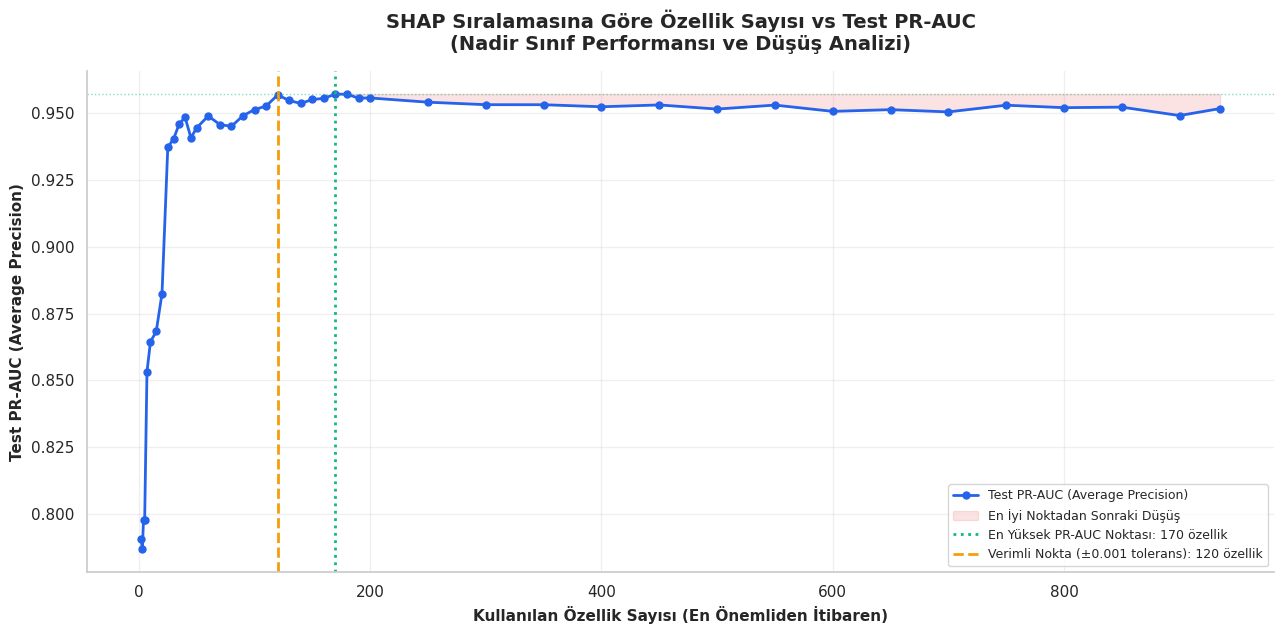

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import average_precision_score

sns.set_theme(style="whitegrid")

# Taranacak özellik sayıları: küçük adımlarla başlayıp sonra 50'şer artıyoruz
kucuk_adimlar = [2,3,4,5,7,10,15, 20,25, 30,35, 40,45, 50,60, 70,80,90, 100,110,120,130,140, 150,160,170,180,190, 200, 250, 300, 350, 400]
buyuk_adimlar = list(range(450, len(feature_cols) + 1, 50))
feature_counts = sorted(set(kucuk_adimlar + buyuk_adimlar + [len(feature_cols)]))
feature_counts = [n for n in feature_counts if n <= len(feature_cols)]

# SHAP sıralamasını (en önemliden en az önemliye) importance_df'ten alıyoruz
siralanmis_ozellikler = importance_df['ozellik'].tolist()

sweep_results = []

print(f"Toplam {len(feature_counts)} farklı özellik sayısı taranacak: {feature_counts}\n")

for n in feature_counts:
    secili_ozellikler = siralanmis_ozellikler[:n]

    X_tr_n = train_fe[secili_ozellikler]
    X_te_n = test_fe[secili_ozellikler]

    spw_n = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    # Sweep hızlı olması için sabit, orta büyüklükte bir model kullanıyoruz
    # (asıl amaç kıyaslama, en optimize modeli burada aramıyoruz)
    clf_n = LGBMClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=7, num_leaves=31,
        scale_pos_weight=spw_n, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
    clf_n.fit(X_tr_n, y_train)

    proba_n = clf_n.predict_proba(X_te_n)[:, 1]
    pr_auc_n = average_precision_score(y_test, proba_n)

    sweep_results.append({'ozellik_sayisi': n, 'test_pr_auc': pr_auc_n})
    print(f"  N={n:>4} özellik -> Test PR-AUC: {pr_auc_n:.4f}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv('/kaggle/working/cmapss_feature_sweep_prauc.csv', index=False)

# En iyi skor ve o skora "yeterince yakın" (fark < 0.001) en küçük N'i buluyoruz
best_pr_auc = sweep_df['test_pr_auc'].max()
best_n = sweep_df.loc[sweep_df['test_pr_auc'].idxmax(), 'ozellik_sayisi']

tolerans = 0.001
verimli_n = sweep_df.loc[sweep_df['test_pr_auc'] >= best_pr_auc - tolerans, 'ozellik_sayisi'].min()

# Düşüş analizi: en iyi noktadan sonra PR-AUC ne kadar geriliyor?
sweep_df['best_ten_fark'] = sweep_df['test_pr_auc'] - best_pr_auc

print(f"\nEn yüksek PR-AUC: {best_pr_auc:.4f} -> {best_n} özellik ile elde edildi.")
print(f"PR-AUC'den en fazla {tolerans} kaybederek en az özellikle aynı performansı veren nokta: {verimli_n} özellik.")
print(f"\nEn iyi noktadan sonraki düşüş (son 5 deneme):")
print(sweep_df.tail(5).to_string(index=False))

# ============================================================
# GÖRSELLEŞTİRME — Tüm denemeler ve düşüş tek grafikte
# ============================================================
fig, ax = plt.subplots(figsize=(13, 6.5))

ax.plot(sweep_df['ozellik_sayisi'], sweep_df['test_pr_auc'], marker='o', color='#2563eb',
        linewidth=2, markersize=5, label='Test PR-AUC (Average Precision)')

# En iyi noktadan sonrasını kırmızı bölge olarak vurgulayalım (düşüş bölgesi)
dusus_bolgesi = sweep_df[sweep_df['ozellik_sayisi'] >= best_n]
ax.fill_between(dusus_bolgesi['ozellik_sayisi'], dusus_bolgesi['test_pr_auc'], best_pr_auc,
                 color='#ef4444', alpha=0.15, label='En İyi Noktadan Sonraki Düşüş')

ax.axvline(best_n, color='#10b981', linestyle=':', linewidth=2,
           label=f'En Yüksek PR-AUC Noktası: {best_n} özellik')

ax.axvline(verimli_n, color='#f59e0b', linestyle='--', linewidth=2,
           label=f'Verimli Nokta (±{tolerans} tolerans): {verimli_n} özellik')

ax.axhline(best_pr_auc, color='#10b981', linestyle=':', linewidth=1, alpha=0.5)

ax.set_title('SHAP Sıralamasına Göre Özellik Sayısı vs Test PR-AUC\n(Nadir Sınıf Performansı ve Düşüş Analizi)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kullanılan Özellik Sayısı (En Önemliden İtibaren)', fontsize=11, fontweight='bold')
ax.set_ylabel('Test PR-AUC (Average Precision)', fontsize=11, fontweight='bold')
ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=9)
ax.grid(alpha=0.3)
sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.savefig('/kaggle/working/cmapss_feature_sweep_prauc.png', dpi=150)
plt.show()

# 03 · KAÇ ÖZELLİK YETERLİ?

### SHAP sıralaması üzerinden özellik sayısı denemesi

---

## Deneyin amacı

Önceki bölümde modelin kullandığı özellikleri SHAP katkılarına göre sıraladık. Buradaki soru, **935 özelliğin tamamının gerekli olup olmadığıdır**. En önemli ilk özellikleri kademeli olarak seçip her özellik sayısı için aynı ayarlara sahip bir LightGBM modeli eğittik. Böylece model başarısının, kullanılan özellik sayısına göre nasıl değiştiğini karşılaştırdık.

Riskli sınıf test verisinde seyrek olduğu için karşılaştırma ölçütü olarak **PR-AUC (Average Precision)** kullandık. Bu skor, farklı alarm eşiklerindeki precision–recall dengesini özetler; tabloda yüksek değer daha iyi performansa karşılık gelir.

| **Deney düzeni** | **Uygulanan tercih** |
|:---|:---|
| Özelliklerin sırası | Bir önceki hücrede hesaplanan ortalama mutlak SHAP sıralaması |
| Denenen özellik sayıları | 2 ile 935 arasında **44 farklı değer** |
| Model | Her denemede aynı ayarlarla yeniden eğitilen LightGBM |
| Seçim ölçütü | Test PR-AUC; en iyi skordan en fazla **0,001** geride kalan en küçük özellik sayısı |

---

## Sonuçların okunması

| **Özellik sayısı** | **Test PR-AUC** | **Bu deneydeki anlamı** |
|---:|---:|:---|
| 2 | 0,7907 | Çok az özellikle bazı sinyaller yakalansa da performans sınırlı. |
| 25 | 0,9373 | İlk özelliklerle büyük bir kazanım elde edildi. |
| 110 | 0,9527 | Başarı artmaya devam ediyor. |
| **120** | **0,9568** | En yüksek skora 0,001 tolerans içinde ulaşan **en küçük** deneme. |
| **170** | **0,9572** | Taranan değerler arasındaki **en yüksek** skor. |
| 180 | 0,9571 | Zirveye çok yakın, ancak daha fazla özellik kullanıyor. |
| 900 | 0,9491 | Daha fazla özellik burada daha iyi skor vermedi. |
| 935 | 0,9517 | Tüm özelliklerle kurulan **tarama modelinin** skoru. |

> **Ana bulgu**  
> En yüksek PR-AUC **170 özellikle 0,9572** oldu. **120 özellikle 0,9568** elde edildi; fark yalnızca **0,0004**. Önceden belirlenen **0,001 toleransı** içinde kalan en küçük aday **120 özellik** olduğu için sonraki eleme aşamasına bu havuzla devam ediyoruz.

### Grafikte görülen eğilim

Özellik sayısı başlangıçta arttıkça PR-AUC belirgin biçimde yükseliyor. Yaklaşık 120–200 özellik aralığında skor yüksek düzeyde kalıyor; daha fazla özellik eklemek ise düzenli bir iyileşme sağlamıyor. Eğri **tek yönlü değil**: bazı noktalarda düşüp tekrar yükseliyor. Dolayısıyla 170 sonrasındaki her düşüşü tek başına "fazla özellik kesin olarak zararlıdır" diye yorumlamıyoruz.

---

## 120 özellik neden tercih edildi?

Bu aşamadaki hedef **yalnızca en yüksek sayıyı bulmak değil**, ona çok yakın başarıyı daha az girdiyle elde etmekti. 120 özellik, en iyi denemeye göre **50 özellik daha az** kullanırken belirlenen toleransın içinde kalıyor. Böylece bir sonraki adımda sensör bazında eleme yapabileceğimiz daha küçük ve incelenebilir bir başlangıç kümesi elde ettik.

> **Önemli karşılaştırma sınırı**  
> Buradaki 935 özellikli son satır, tarama için kullanılan **400 ağaçlık sabit ayarlı modelin PR-AUC sonucudur**. Önceki bölümde erken durdurmayla eğitilen ilk modelin **0,9984 ROC-AUC** değeriyle doğrudan karşılaştırılamaz; hem modellerin ayarları hem ölçülen metrikler farklıdır.

## Sonraki adım ve yöntem sınırı

Şimdi 120 özellik içindeki sensörleri birlikte inceleyip katkısı düşük olan sensörlerden gelen sütunları eleyeceğiz. Daha küçük kümenin **nihai modelde** de işe yarayıp yaramadığını ancak yeniden eğitimden sonra değerlendirebiliriz.

Bu taramada özellikler test verisindeki SHAP analizine göre sıralanmış ve 120 seçimi yine test PR-AUC ile yapılmıştır. Bu yüzden aynı test kümesindeki sonraki skorlar, **tamamen dokunulmamış bağımsız nihai test sonucu** olarak sunulmamalıdır. Daha sıkı bir uygulamada özellik sayısı ayrı bir doğrulama kümesinde seçilir; test kümesi yalnızca son değerlendirmede kullanılır.

[EŞİK 1 - SWEEP TABANLI] Öncesi Toplam Özellik Sayısı : 935
[EŞİK 1 - SWEEP TABANLI] Tutulan Özellik (N=120)    : 120
[EŞİK 1 - SWEEP TABANLI] Bu N'de kümülatif SHAP açıklanabilirliği: %76.68

[EŞİK 2] 120'lik elit havuzda ham sensör bazında toplam SHAP katkı payı (en düşükten en yükseğe, 'diger' hariç):
ham_sensor  ortalama_mutlak_shap  sensor_katki_orani  kumulatif_kayip
       s14              0.064515            0.016019         0.016019
        s9              0.074570            0.018516         0.034535
        s8              0.081291            0.020184         0.054719
       s20              0.116273            0.028871         0.083590
        s7              0.134333            0.033355         0.116944
       s17              0.143543            0.035642         0.152586
       s13              0.145266            0.036069         0.188656
        s2              0.214795            0.053333         0.241989
       s21              0.231520            0.057486         0.2

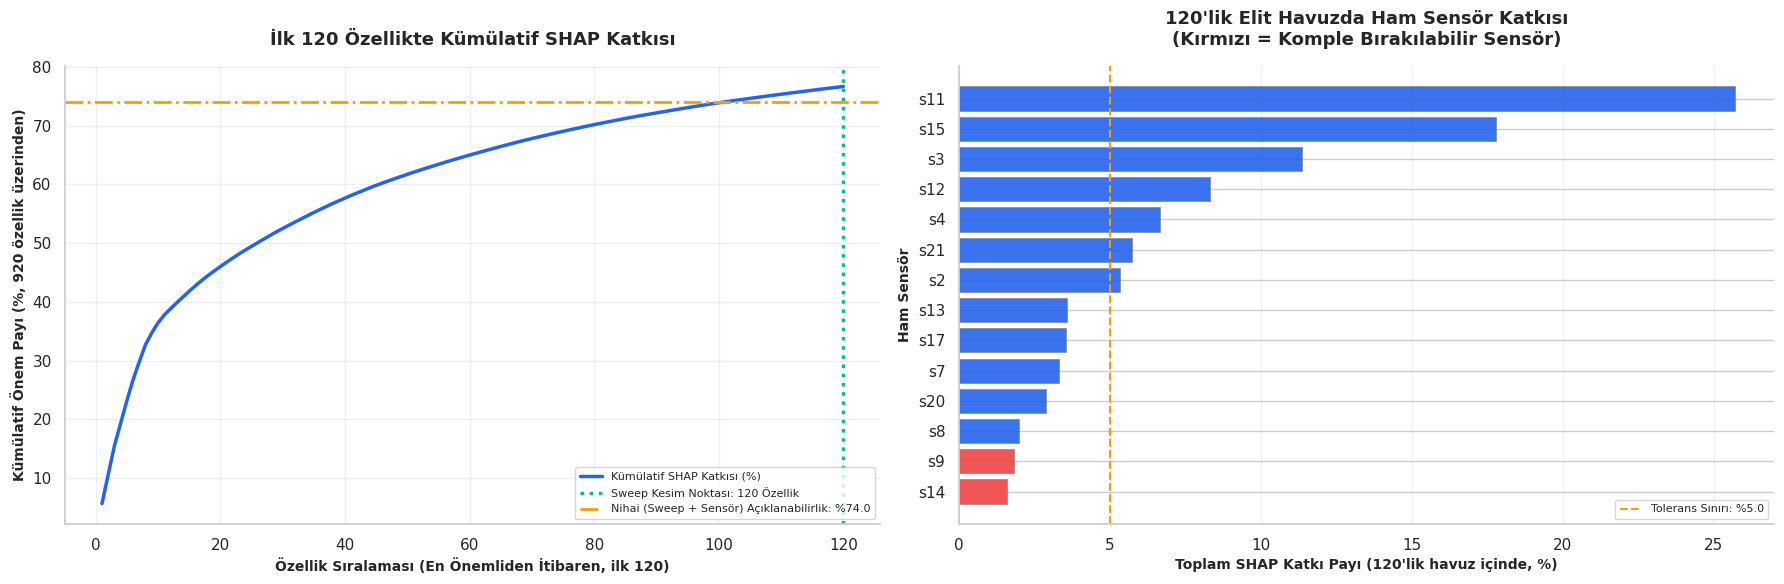


ÖZET: 920 özellik -> sweep ile 120 -> sensör elemeyle 111
Bırakılabilecek sensörler: ['s14', 's9']


In [19]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# EŞİK 1 GÜNCELLENDİ: Kümülatif %90 yerine, sweep sonucundan gelen
# "AUC/PR-AUC'yi en az özellikle koruyan nokta" olan N=120'yi kullanıyoruz.
# Kümülatif SHAP oranı artık sadece bilgi amaçlı raporlanıyor, kesim
# kararı doğrudan sweep sonucuna dayanıyor.
# ============================================================
N_KEEP_SWEEP = 120  # Sweep grafiğindeki verimli nokta

importance_df['kumulatif_oran'] = importance_df['ortalama_mutlak_shap'].cumsum() / importance_df['ortalama_mutlak_shap'].sum()

n_keep = min(N_KEEP_SWEEP, len(importance_df))
kept_features_stage1 = importance_df.head(n_keep)['ozellik'].tolist()

kumulatif_aciklanabilirlik_120 = importance_df.iloc[n_keep - 1]['kumulatif_oran']

print(f"[EŞİK 1 - SWEEP TABANLI] Öncesi Toplam Özellik Sayısı : {len(importance_df)}")
print(f"[EŞİK 1 - SWEEP TABANLI] Tutulan Özellik (N={n_keep})    : {n_keep}")
print(f"[EŞİK 1 - SWEEP TABANLI] Bu N'de kümülatif SHAP açıklanabilirliği: %{kumulatif_aciklanabilirlik_120*100:.2f}")

# ============================================================
# EŞİK 2 — HAM SENSÖR BAZLI TOPLU ELEME (artık 120'lik havuz içinde)
# 'diger' (etkileşim özellikleri) fiziksel bir sensöre karşılık gelmediği
# için donanımdan çıkarılabilir sensör listesine hiçbir zaman girmez.
# ============================================================
SENSOR_CUMULATIVE_DROP_TOLERANCE = 0.05  # Bu 120'lik elit havuzda sensör başına toplam kayıp toleransı

SENSOR_PATTERN = re.compile(r'^(s\d+)')

def extract_sensor(feature_name: str):
    match = SENSOR_PATTERN.match(feature_name)
    return match.group(1) if match else 'diger'

# Önemli: sensör analizini artık TÜM 920 özellik üzerinden değil,
# sweep'in seçtiği 120'lik havuz üzerinden yapıyoruz. Çünkü asıl soru
# "bu 120'lik elit sette bir sensörü komple atsak ne kaybederiz?"
kept_df_120 = importance_df[importance_df['ozellik'].isin(kept_features_stage1)].copy()
kept_df_120['ham_sensor'] = kept_df_120['ozellik'].apply(extract_sensor)

total_shap_120 = kept_df_120['ortalama_mutlak_shap'].sum()
sensor_importance = (
    kept_df_120.groupby('ham_sensor')['ortalama_mutlak_shap']
    .sum()
    .reset_index()
)
sensor_importance['sensor_katki_orani'] = sensor_importance['ortalama_mutlak_shap'] / total_shap_120

sensor_importance_real = sensor_importance[sensor_importance['ham_sensor'] != 'diger'].copy()
sensor_importance_real = sensor_importance_real.sort_values('sensor_katki_orani', ascending=True).reset_index(drop=True)
sensor_importance_real['kumulatif_kayip'] = sensor_importance_real['sensor_katki_orani'].cumsum()

print(f"\n[EŞİK 2] 120'lik elit havuzda ham sensör bazında toplam SHAP katkı payı (en düşükten en yükseğe, 'diger' hariç):")
print(sensor_importance_real.to_string(index=False))

sensors_to_drop = sensor_importance_real.loc[
    sensor_importance_real['kumulatif_kayip'] <= SENSOR_CUMULATIVE_DROP_TOLERANCE,
    'ham_sensor'
].tolist()

print(f"\n[EŞİK 2] 120'lik havuzda toplam SHAP katkısına en fazla %{SENSOR_CUMULATIVE_DROP_TOLERANCE*100:.1f} kayıpla komple bırakılabilecek sensörler:")
print(sensors_to_drop if sensors_to_drop else "  -> Bu 120'lik havuzda hiçbir sensör bu tolerans içinde tamamen bırakılamıyor.")

# Kaç özellik hangi sensöre ait, kesilecek sensörlerden kaç özellik gidecek?
kesilecek_ozellik_sayisi = kept_df_120[kept_df_120['ham_sensor'].isin(sensors_to_drop)].shape[0]
print(f"[EŞİK 2] Bu sensörlerin 120'lik havuzdaki toplam özellik sayısı: {kesilecek_ozellik_sayisi}")

# ============================================================
# NİHAİ ELEME — 120'lik havuzdan sensör bazlı ek eleme
# ============================================================
kept_features = [f for f in kept_features_stage1 if extract_sensor(f) not in sensors_to_drop]
dropped_features = [f for f in importance_df['ozellik'].tolist() if f not in kept_features]

final_kumulatif_aciklanabilirlik = importance_df.loc[
    importance_df['ozellik'].isin(kept_features), 'ortalama_mutlak_shap'
].sum() / importance_df['ortalama_mutlak_shap'].sum()

print(f"\n[NİHAİ] Sweep sonrası (N=120): {len(kept_features_stage1)} özellik")
print(f"[NİHAİ] Sensör bazlı ek çıkarılan     : {len(kept_features_stage1) - len(kept_features)} özellik")
print(f"[NİHAİ] Toplam tutulan özellik          : {len(kept_features)}")
print(f"[NİHAİ] Toplam atılan özellik (920'den) : {len(dropped_features)}")
print(f"[NİHAİ] Bırakılabilecek sensörler       : {sensors_to_drop if sensors_to_drop else 'Yok'}")
print(f"[NİHAİ] Kalan gerçek kümülatif açıklanabilirlik (920 üzerinden): %{final_kumulatif_aciklanabilirlik*100:.2f}")

# Dosyalara kaydedelim
pd.Series(kept_features).to_csv('/kaggle/working/cmapss_kept_features_120_sensor_filtered.csv', index=False)
pd.Series(dropped_features).to_csv('/kaggle/working/cmapss_dropped_features_120.csv', index=False)
sensor_importance_real.to_csv('/kaggle/working/cmapss_sensor_importance_120.csv', index=False)
pd.Series(sensors_to_drop).to_csv('/kaggle/working/cmapss_dropped_sensors_120.csv', index=False)


# ============================================================
# GÖRSELLEŞTİRME — İki panel
# ============================================================
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Panel 1: 120'lik havuzda kümülatif SHAP eğrisi (yakınlaştırılmış) ---
zoom_df = importance_df.head(n_keep).reset_index(drop=True)
zoom_kumulatif = zoom_df['ortalama_mutlak_shap'].cumsum() / importance_df['ortalama_mutlak_shap'].sum()

ax1.plot(range(1, n_keep + 1), zoom_kumulatif * 100,
          color='#2563eb', linewidth=2.5, label='Kümülatif SHAP Katkısı (%)')

ax1.axvline(n_keep, color='#10b981', linestyle=':', linewidth=2.5,
            label=f'Sweep Kesim Noktası: {n_keep} Özellik')

ax1.axhline(final_kumulatif_aciklanabilirlik * 100, color='#f59e0b', linestyle='-.', linewidth=2,
            label=f'Nihai (Sweep + Sensör) Açıklanabilirlik: %{final_kumulatif_aciklanabilirlik*100:.1f}')

ax1.set_title('İlk 120 Özellikte Kümülatif SHAP Katkısı', fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Özellik Sıralaması (En Önemliden İtibaren, ilk 120)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Kümülatif Önem Payı (%, 920 özellik üzerinden)', fontsize=10, fontweight='bold')
ax1.legend(loc='lower right', frameon=True, facecolor='white', fontsize=8)
ax1.grid(alpha=0.3)
sns.despine(ax=ax1, top=True, right=True)

# --- Panel 2: 120'lik havuzda ham sensör bazlı toplam katkı ---
bar_colors = ['#ef4444' if s in sensors_to_drop else '#2563eb' for s in sensor_importance_real['ham_sensor']]

ax2.barh(sensor_importance_real['ham_sensor'], sensor_importance_real['sensor_katki_orani'] * 100,
          color=bar_colors, alpha=0.9, edgecolor='gray', linewidth=0.5)

ax2.axvline(SENSOR_CUMULATIVE_DROP_TOLERANCE * 100, color='#f59e0b', linestyle='--', linewidth=1.5,
            label=f'Tolerans Sınırı: %{SENSOR_CUMULATIVE_DROP_TOLERANCE*100:.1f}')

ax2.set_title('120\'lik Elit Havuzda Ham Sensör Katkısı\n(Kırmızı = Komple Bırakılabilir Sensör)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xlabel('Toplam SHAP Katkı Payı (120\'lik havuz içinde, %)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Ham Sensör', fontsize=10, fontweight='bold')
ax2.legend(loc='lower right', frameon=True, facecolor='white', fontsize=8)
ax2.grid(alpha=0.3, axis='x')
sns.despine(ax=ax2, top=True, right=True)

plt.tight_layout()
plt.savefig('/kaggle/working/cmapss_sweep120_sensor_eleme.png', dpi=150)
plt.show()

print(f"\n{'='*60}")
print(f"ÖZET: 920 özellik -> sweep ile 120 -> sensör elemeyle {len(kept_features)}")
print(f"Bırakılabilecek sensörler: {sensors_to_drop if sensors_to_drop else 'Yok'}")
print(f"{'='*60}")

In [20]:
# Peki geriye kalan ve atılan özellikler ağırlıklı olarak hangi türden? Merak edip bakalım.
def kategorize_et(ozellik_listesi):
    sayac = {'Rolling Mean': 0, 'Rolling Std': 0, 'Lag (Gecikme)': 0, 'Slope (Eğim)': 0, 'Diff (Fark)': 0, 'Diğer / Etkileşim': 0}
    for f in ozellik_listesi:
        if 'roll_mean' in f:
            sayac['Rolling Mean'] += 1
        elif 'roll_std' in f:
            sayac['Rolling Std'] += 1
        elif 'lag' in f:
            sayac['Lag (Gecikme)'] += 1
        elif 'slope' in f:
            sayac['Slope (Eğim)'] += 1
        elif 'diff' in f:
            sayac['Diff (Fark)'] += 1
        else:
            sayac['Diğer / Etkileşim'] += 1
    return sayac

kat_tutulan = kategorize_et(kept_features)
kat_atilan = kategorize_et(dropped_features)

ozet_df = pd.DataFrame({
    f'Tutulan (Sweep N={n_keep} + Sensör)': kat_tutulan,
    'Atılan': kat_atilan
}).fillna(0).astype(int)

print("Özellik Türlerinin Dağılımı (Tutulan vs Atılan):")
display(ozet_df)

# Artık elimizde hem sweep ile doğrulanmış performans-optimal N=120 hem de
# gereksiz sensörlerden temizlenmiş son özellik listemiz var.
# Train ve test setini bu kolonlara göre daraltıyoruz.
final_train_df = train_fe[['unit', 'cycle', 'RUL', 'label'] + kept_features].copy()
final_test_df = test_fe[['unit', 'cycle', 'RUL', 'label'] + kept_features].copy()

# Kaggle ortamında hızlı yüklendiği için diske Parquet olarak kaydediyoruz
final_train_df.to_parquet('/kaggle/working/cmapss_train_final.parquet', index=False)
final_test_df.to_parquet('/kaggle/working/cmapss_test_final.parquet', index=False)

print("\nFinal veri setleri kaydedildi.\n")
print(f"Final Train Boyutu : {final_train_df.shape}\n")
print(f"\nFinal Test Boyutu  : {final_test_df.shape}\n")
print(f"Tasarruf Oranı      : %{(1 - len(kept_features)/len(feature_cols))*100:.1f} daha az özellik ile aynı seviyede performans!\n")

final_train_df.info()
final_test_df.info()

Özellik Türlerinin Dağılımı (Tutulan vs Atılan):


,Tutulan (Sweep N=120 + Sensör),Atılan
Rolling Mean,51,219
Rolling Std,34,236
Lag (Gecikme),1,194
Slope (Eğim),23,142
Diff (Fark),0,15
Diğer / Etkileşim,2,18



Final veri setleri kaydedildi.

Final Train Boyutu : (20631, 115)


Final Test Boyutu  : (13096, 115)

Tasarruf Oranı      : %88.1 daha az özellik ile aynı seviyede performans!

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Columns: 115 entries, unit to s20_roll_std_40
dtypes: float64(111), int64(4)
memory usage: 18.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13096 entries, 0 to 13095
Columns: 115 entries, unit to s20_roll_std_40
dtypes: float64(111), int64(4)
memory usage: 11.5 MB


In [21]:
# ---------------------------------------------------------------
# 8) NİHAİ MODEL - SADECE KIRPILMIŞ ÖZELLİKLERLE YENİDEN EĞİTİM
# ---------------------------------------------------------------
import joblib
import numpy as np
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

# Sadece SHAP + sensör bazlı elemeden geçen (kept_features) elit özellikleri alıyoruz
X_train_final, X_test_final = train_fe[kept_features], test_fe[kept_features]

# Early stopping için train setinden küçük bir validation dilimi ayırıyoruz
X_tr_final, X_val_final, y_tr_final, y_val_final = train_test_split(
    X_train_final, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# Dengesiz veri için sınıf ağırlığını bu daralmış sette yeniden hesaplıyoruz
spw_final = (y_tr_final == 0).sum() / max((y_tr_final == 1).sum(), 1)

clf_final = LGBMClassifier(
    n_estimators=10000,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=63,
    min_child_samples=20,
    min_split_gain=0.0,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=0.5,
    scale_pos_weight=spw_final,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
print(f"[NİHAİ MODEL - {len(kept_features)} özellik] LightGBM eğitiliyor (10.000 iterasyon, 100 erken durdurma)...")

clf_final.fit(
    X_tr_final, y_tr_final,
    eval_set=[(X_val_final, y_val_final)],
    eval_metric="auc",
    callbacks=[early_stopping(stopping_rounds=100), log_evaluation(period=200)]
)

print(f"En iyi iterasyon: {clf_final.best_iteration_}")

# Test seti üzerinde olasılık tahminleri
proba_test_final = clf_final.predict_proba(X_test_final)[:, 1]

# Performans metrikleri
roc_auc_final = roc_auc_score(y_test, proba_test_final)
pr_auc_final = average_precision_score(y_test, proba_test_final)

print(f"\n[NİHAİ MODEL - {len(kept_features)} özellik] ROC-AUC: {roc_auc_final:.4f} | PR-AUC: {pr_auc_final:.4f}")
print(f"(Ara model ile ROC-AUC farkı: {roc_auc_full - roc_auc_final:.4f})")

# En iyi F1 skoru için optimal eşik (threshold) optimizasyonu
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_test_final)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
print(f"F1-optimal eşik: {threshold:.4f} (Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f})")

# Final çıktı veri setlerinin oluşturulması (Kolon adını veri setimize 'unit' olarak uyarlıyoruz)
df_train_final_out = train_fe[['unit', 'cycle', 'RUL', 'label'] + kept_features].rename(columns={'unit': 'unit_number', 'cycle': 'time_cycles'})
df_test_final_out = test_fe[['unit', 'cycle', 'RUL', 'label'] + kept_features].rename(columns={'unit': 'unit_number', 'cycle': 'time_cycles'}).copy()

# CSV ve Model Kayıt İşlemleri
df_train_final_out.to_csv('/kaggle/working/cmapss_train_final.csv', index=False)
df_test_final_out.to_csv('/kaggle/working/cmapss_test_final.csv', index=False)

joblib.dump({
    'model': clf_final,
    'feature_cols': kept_features,
    'threshold': float(threshold),
    'best_iteration': int(clf_final.best_iteration_)
}, '/kaggle/working/cmapss_model_final.joblib')

print("\nBaşarıyla Kaydedildi: cmapss_train_final.csv, cmapss_test_final.csv, cmapss_model_final.joblib")

[NİHAİ MODEL - 111 özellik] LightGBM eğitiliyor (10.000 iterasyon, 100 erken durdurma)...
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.998777	valid_0's binary_logloss: 0.0692553
[400]	valid_0's auc: 0.999215	valid_0's binary_logloss: 0.0339501
[600]	valid_0's auc: 0.999485	valid_0's binary_logloss: 0.0239108
[800]	valid_0's auc: 0.999588	valid_0's binary_logloss: 0.0197041
[1000]	valid_0's auc: 0.99963	valid_0's binary_logloss: 0.0180472
[1200]	valid_0's auc: 0.999651	valid_0's binary_logloss: 0.017267
[1400]	valid_0's auc: 0.999663	valid_0's binary_logloss: 0.0170073
Early stopping, best iteration is:
[1447]	valid_0's auc: 0.999669	valid_0's binary_logloss: 0.0169431
En iyi iterasyon: 1447

[NİHAİ MODEL - 111 özellik] ROC-AUC: 0.9975 | PR-AUC: 0.9222
(Ara model ile ROC-AUC farkı: 0.0009)
F1-optimal eşik: 0.4696 (Precision: 0.828, Recall: 0.795)

Başarıyla Kaydedildi: cmapss_train_final.csv, cmapss_test_final.csv, cmapss_model_final.joblib



 C-MAPSS: RUL ARALIKLARINA GÖRE RİSK SKORU VE YAKALANMA ORANI RAPORU 
rul_bin  ornek_sayisi  ortalama_olasilik  yakalanan_oran_%
   6-7c             1             1.0000            100.00
   7-8c             4             1.0000            100.00
   8-9c             5             1.0000            100.00
  9-10c             7             1.0000            100.00
 10-11c             8             1.0000            100.00
 11-12c             8             1.0000            100.00
 12-18c            61             0.9950            100.00
 18-24c           105             0.8844             91.43
 24-30c           133             0.5505             55.64


 OPERASYONEL HORİZON BAZINDA ERKEN UYARI BAŞARI ORANI (H=24) 
 horizon_cycle  gercek_pozitif  dogru_alarm  kacirilan  recall_%
             1               0            0          0      0.00
             2               0            0          0      0.00
             3               0            0          0      0.00
             4 

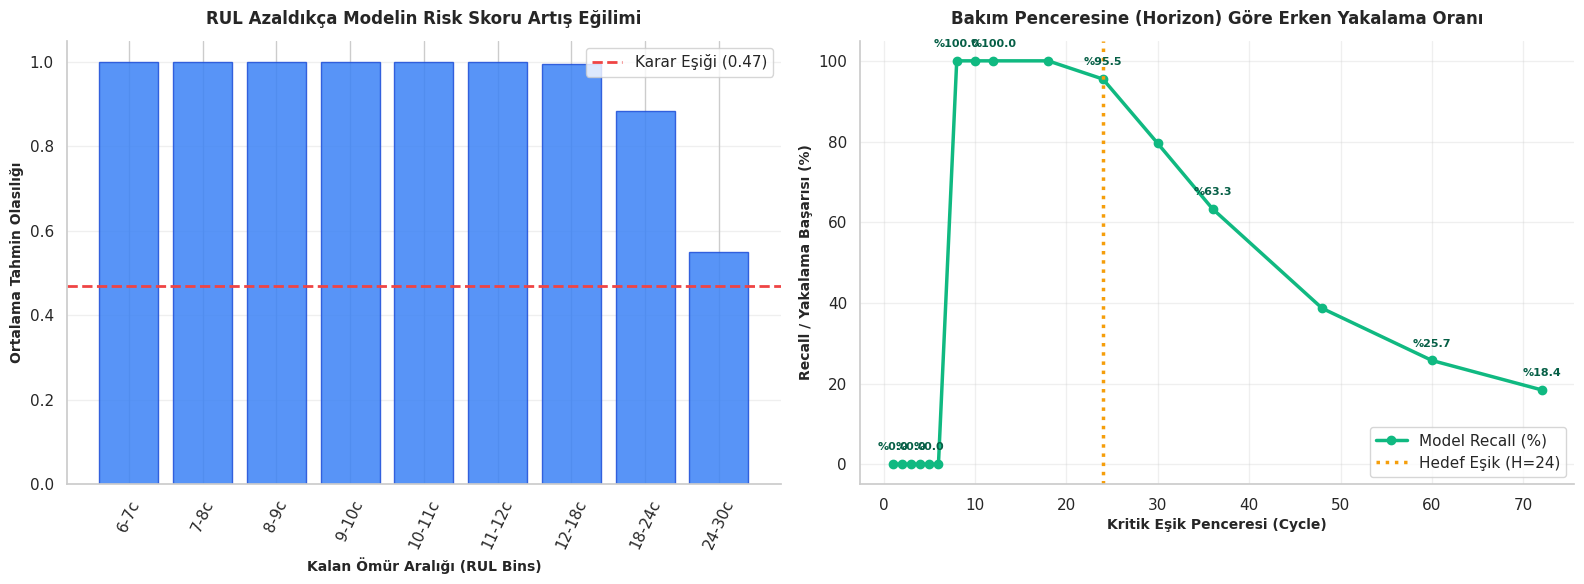


 OPTİMİZE EDİLMİŞ PİPELİNE BAŞARIYLA TAMAMLANDI 
 • Hedef Horizon Eşiği        : 24 Döngü
 • Nihai Model ROC-AUC        : 0.9975
 • Nihai Model PR-AUC         : 0.9222
 • Optimal Karar Eşiği (F1)   : 0.4696
 • Çıktı Dosyaları            : cmapss_train_final.csv, cmapss_test_final.csv, cmapss_model_final.joblib


In [22]:
# ---------------------------------------------------------------
# 9) GELİŞMİŞ HORİZON BAZLI PERFORMANS VE RİSK RAPORU (H=24)
# ---------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Hedef bakım penceresini (Horizon) 24 döngü olarak güncelliyoruz
HORIZON_CYCLES = 24

# Stil ve tema ayarları
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.family': 'sans-serif'})

# İnce taneli RUL aralıkları (Bins)
BINS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 18, 24, 30, 36, 48, 60, 72, 10_000]
BIN_LABELS = [f"{BINS[i]}-{BINS[i+1]}c" if BINS[i+1] < 10_000 else f"{BINS[i]}c+" for i in range(len(BINS) - 1)]

# Tahmin sütunlarını final test veri setine ekleyelim
df_test_final_out['proba'] = proba_test_final
df_test_final_out['pred_label'] = (df_test_final_out['proba'] >= threshold).astype(int)

# Sadece gerçekte tehlikeli olan örnekler üzerindeki risk dağılımı
pos_df = df_test_final_out[df_test_final_out['label'] == 1].copy()
pos_df['rul_bin'] = pd.cut(pos_df['RUL'], bins=BINS, labels=BIN_LABELS, right=True)

summary = pos_df.groupby('rul_bin', observed=True).agg(
    ornek_sayisi=('proba', 'size'),
    ortalama_olasilik=('proba', 'mean'),
    yakalanan_oran=('pred_label', 'mean')
).reset_index()

summary['yakalanan_oran_%'] = (summary['yakalanan_oran'] * 100).round(2)
summary['ortalama_olasilik'] = summary['ortalama_olasilik'].round(4)
summary = summary.drop(columns='yakalanan_oran')

print("\n" + "="*75)
print(" C-MAPSS: RUL ARALIKLARINA GÖRE RİSK SKORU VE YAKALANMA ORANI RAPORU ")
print("="*75)
print(summary.to_string(index=False))
print("="*75 + "\n")

# Farklı operasyonel horizonlarda (pencerelerde) Recall analizi
horizons_test = [1, 2, 3, 4, 5, 6, 8, 10, 12, 18, 24, 30, 36, 48, 60, 72]
results = []

for h in horizons_test:
    relabel = ((df_test_final_out['RUL'] >= 0) & (df_test_final_out['RUL'] <= h)).astype(int)
    tp = ((relabel == 1) & (df_test_final_out['pred_label'] == 1)).sum()
    fn = ((relabel == 1) & (df_test_final_out['pred_label'] == 0)).sum()
    recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    results.append({
        'horizon_cycle': h, 
        'gercek_pozitif': int(relabel.sum()), 
        'dogru_alarm': int(tp),
        'kacirilan': int(fn), 
        'recall_%': round(recall * 100, 2) if not np.isnan(recall) else 0.0
    })

horizon_recall_df = pd.DataFrame(results)

print("\n" + "="*75)
print(f" OPERASYONEL HORİZON BAZINDA ERKEN UYARI BAŞARI ORANI (H={HORIZON_CYCLES}) ")
print("="*75)
print(horizon_recall_df.to_string(index=False))
print("="*75 + "\n")

# Profesyonel Görselleştirme (Enterprise Dashboard Stili)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Grafik 1: RUL Aralarına Göre Ortalama Risk Skoru
axes[0].bar(summary['rul_bin'].astype(str), summary['ortalama_olasilik'], 
            color='#3b82f6', alpha=0.85, edgecolor='#1d4ed8', linewidth=1)
axes[0].axhline(threshold, color='#ef4444', linestyle='--', linewidth=2, 
                label=f'Karar Eşiği ({threshold:.2f})')

axes[0].set_title('RUL Azaldıkça Modelin Risk Skoru Artış Eğilimi', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Kalan Ömür Aralığı (RUL Bins)', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Ortalama Tahmin Olasılığı', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=65)
axes[0].legend(loc='upper right', frameon=True)
axes[0].grid(alpha=0.3, axis='y')
sns.despine(ax=axes[0], top=True, right=True)

# Grafik 2: Horizon - Recall İlişkisi (Güncellenmiş 24 Döngü İşaretli)
axes[1].plot(horizon_recall_df['horizon_cycle'], horizon_recall_df['recall_%'], 
             marker='o', color='#10b981', linewidth=2.5, markersize=6, label='Model Recall (%)')
axes[1].axvline(HORIZON_CYCLES, color='#f59e0b', linestyle=':', linewidth=2.5, 
                label=f'Hedef Eşik (H={HORIZON_CYCLES})')

# Eğri üzerine kritik noktaları etiketleme
for i, txt in enumerate(horizon_recall_df['recall_%']):
    if i % 2 == 0 or horizon_recall_df['horizon_cycle'].iloc[i] in [1, 24, 72]:
        axes[1].annotate(f"%{txt:.1f}", 
                         (horizon_recall_df['horizon_cycle'].iloc[i], horizon_recall_df['recall_%'].iloc[i]),
                         textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, fontweight='bold', color='#065f46')

axes[1].set_title('Bakım Penceresine (Horizon) Göre Erken Yakalama Oranı', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Kritik Eşik Penceresi (Cycle)', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Recall / Yakalama Başarısı (%)', fontsize=10, fontweight='bold')
axes[1].set_ylim(-5, 105)
axes[1].legend(loc='lower right', frameon=True)
axes[1].grid(alpha=0.3)
sns.despine(ax=axes[1], top=True, right=True)

plt.tight_layout()
plt.savefig('/kaggle/working/cmapss_gelismis_performans_raporu.png', dpi=150)
plt.show()

# Final Pipeline Özet Özeti
print("\n" + "="*50)
print(" OPTİMİZE EDİLMİŞ PİPELİNE BAŞARIYLA TAMAMLANDI ")
print("="*50)
print(f" • Hedef Horizon Eşiği        : {HORIZON_CYCLES} Döngü")
print(f" • Nihai Model ROC-AUC        : {roc_auc_final:.4f}")
print(f" • Nihai Model PR-AUC         : {pr_auc_final:.4f}")
print(f" • Optimal Karar Eşiği (F1)   : {threshold:.4f}")
print(f" • Çıktı Dosyaları            : cmapss_train_final.csv, cmapss_test_final.csv, cmapss_model_final.joblib")
print("="*50)

# 04 · NİHAİ MODEL VE ALARM KARARI

### 111 özellik  ·  Yeniden eğitim  ·  F1 tabanlı karar eşiği

---

## Özellik seçiminin sonucu

Önceki deneyde en yüksek skora yakın performans veren **120 özelliklik** bir havuz belirledik. Bu havuzda sensörlerden gelen özelliklerin katkıları birlikte incelendi; `s14` ve `s9` sensörlerine ait toplam **9 özellik** çıkarıldı. Böylece model girdisi **111 özelliğe** indirildi.

| **Aşama** | **Model girdisi** | **Karar** |
|:---|---:|:---|
| Başlangıç | 935 özellik | Zaman serisinden türetilen tüm özellikler |
| SHAP sıralaması ve özellik sayısı taraması | 120 özellik | En yüksek PR-AUC'ye yakın sonuç veren küçük havuz |
| Sensör bazında eleme | **111 özellik** | `s14` ve `s9` kaynaklı 9 özelliğin çıkarılması |

**Not:** Kaydedilen son veri tablolarında **115 sütun** görünmesi doğrudur. Bunların **111'i model girdisi**, dördü ise motor/döngü kimliği ve hedefi saklayan `unit`, `cycle`, `RUL`, `label` sütunlarıdır; son dört sütun modele girdi olarak verilmez.

---

## Modeli neden yeniden eğittik?

Özellik kümesi değiştiğinde, ilk modelin sonucunu doğrudan yeni kümenin başarısı sayamayız. Bu nedenle LightGBM, seçilen **111 özellikle yeniden eğitildi**. Pozitif sınıf için ağırlıklandırma kullanıldı; doğrulama skorundaki iyileşme durduğunda eğitim sonlandırıldı.

| **Nihai modelin gözlenen sonucu** | **Değer** |
|:---|---:|
| En iyi eğitim iterasyonu | **1.447** |
| Test ROC-AUC | **0,9975** |
| Test PR-AUC (Average Precision) | **0,9222** |
| İlk modelle ROC-AUC farkı | **0,0009** |

Başlangıç modeline göre ROC-AUC farkının küçük olması, özellik sayısı azaltıldığında **ayırt etme başarısının bu ölçütte büyük ölçüde korunduğunu** gösteriyor. PR-AUC sonucu da ayrıca raporlanmıştır. Bu ölçümler birbirinden farklı sorulara yanıt verir; önceki özellik taramasındaki PR-AUC değeriyle nihai modelin PR-AUC değeri, **farklı model ayarları kullanıldığı için birebir kontrollü karşılaştırma olarak yorumlanmamalıdır**.

---

## Eşikler birbirinden farklıdır

Aynı notebook'ta geçen üç sayı üç ayrı karar için kullanılır:

| **Değer** | **Rolü** | **Anlamı** |
|:---|:---|:---|
| **24 döngü** | Risk etiketinin tanımı | `RUL ≤ 24` ise gerçek sınıf **riskli (1)** kabul edilir. |
| **%5** | Sensör eleme toleransı | 120 özelliklik havuzda, çıkarılacak sensörlerin **toplam SHAP katkı payı** için sınırdır. Modelin en fazla %5 performans kaybedeceği anlamına gelmez. |
| **0,4696** | Alarm karar eşiği | Nihai modelin tahmin skoru bu eşiğe eşit veya üstündeyse kayıt **alarm** olarak işaretlenir. |

### 0,4696 nasıl seçildi?

LightGBM her kayıt için `proba` adlı bir tahmin skoru üretir. Alarm vermek için bu skorun hangi değerin üstünde olması gerektiğini ayrıca seçmek gerekir. Kod, farklı olası eşikler boyunca **precision** ve **recall** değerlerini hesapladı; bu ikisinin birlikte değerlendirilmesini sağlayan **F1 skorunu en yüksek yapan eşiği** seçti.

| **F1 ile seçilen nokta** | **Değer** |
|:---|---:|
| Karar eşiği | **0,4696** |
| Precision | **0,828** |
| Recall | **0,795** |

> **Alarm kuralı**  
> `proba ≥ 0,4696` → `alarm = true`  
> `proba < 0,4696` → `alarm = false`

Eşik **0,50 olarak varsayılmadı**; bu veri üzerindeki F1 hesabından seçildi. Android'e aktarılacak JSON dosyalarında her döngünün `alarm` alanı bu kurala göre oluşturulacaktır. Buradaki "alarm", veri dosyasındaki **doğru/yanlış işaretidir**; cihazdan ses çıkması veya ekranda uyarı gösterilmesi Android uygulamasının ayrıca tanımladığı davranışlardır.

---

## Yöntem sınırı ve sonraki adım

Bu sürümde özellik seçimi ve F1 karar eşiği **test verisine bakılarak** belirlenmiştir. Dolayısıyla aynı veride bildirilen metrikler, hiç kullanılmamış bağımsız bir son testin sonucu olarak sunulamaz. Daha güçlü bir değerlendirmede bu kararlar motor bazında ayrılmış bir doğrulama kümesinde verilir ve test motorları yalnızca en sonda kullanılır.

Bir sonraki aşamada eğitilmiş modelin tahminleri ve SHAP açıklamaları motor/döngü bazında hesaplanıp Android uygulamasının okuyabileceği JSON dosyalarına dönüştürülecektir.

 SENSÖR AKIŞ ŞEMASI ÖZETİ (SWEEP N=120 HAVUZU İÇİNDE) 
durum       Sensor_Elendi  Tutulan  toplam
ham_sensor                                
s11                     0       14      14
s15                     0       12      12
s4                      0       12      12
s2                      0       12      12
s21                     0       11      11
s13                     0        9       9
s3                      0        9       9
s20                     0        7       7
s12                     0        7       7
s7                      0        7       7
s8                      0        5       5
s17                     0        5       5
s9                      5        0       5
s14                     4        0       4

Komple elenen sensörler : ['s9', 's14']
Hayatta kalan sensörler : ['s11', 's15', 's4', 's2', 's21', 's13', 's3', 's20', 's12', 's7', 's8', 's17']


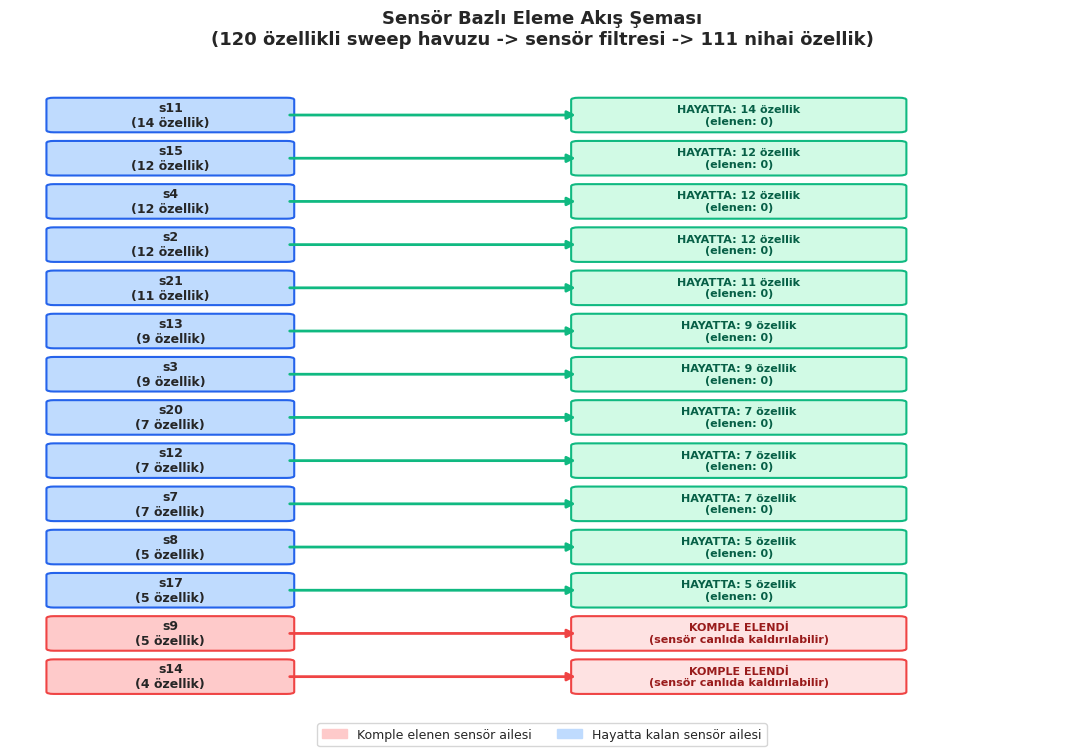

In [23]:
# ---------------------------------------------------------------
# 10) SENSÖR -> ÖZELLİK -> ELEME AKIŞ ŞEMASI
# ---------------------------------------------------------------
# Hangi sensörden kaç özellik türetildi, sweep+SHAP sonrası 120'lik
# havuzda bu sensörlerin katkısı ne oldu, hangi sensörler komple
# elendi (s14, s9) ve hangileri hayatta kaldı? Tek akış şemasında.
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.sankey import Sankey
import seaborn as sns

sns.set_theme(style="white")

SENSOR_PATTERN = re.compile(r'^(s\d+)')

def extract_sensor(feature_name: str):
    match = SENSOR_PATTERN.match(feature_name)
    return match.group(1) if match else 'diger'

# --- 1. Her aşamadaki özellik listelerini sensöre göre grupla ---
# kept_features_stage1: sweep+SHAP sonrası 120'lik havuz (sensör elemesinden ÖNCE)
# kept_features: sensör elemesinden SONRA nihai liste
# dropped_features: 920'den elenen tüm özellikler

havuz_120 = pd.DataFrame({'ozellik': kept_features_stage1})
havuz_120['ham_sensor'] = havuz_120['ozellik'].apply(extract_sensor)
havuz_120['durum'] = np.where(havuz_120['ozellik'].isin(kept_features), 'Tutulan', 'Sensor_Elendi')

sensor_120_ozet = (
    havuz_120[havuz_120['ham_sensor'] != 'diger']
    .groupby(['ham_sensor', 'durum'])
    .size()
    .unstack(fill_value=0)
)
for c in ['Tutulan', 'Sensor_Elendi']:
    if c not in sensor_120_ozet.columns:
        sensor_120_ozet[c] = 0
sensor_120_ozet['toplam'] = sensor_120_ozet['Tutulan'] + sensor_120_ozet['Sensor_Elendi']
sensor_120_ozet = sensor_120_ozet.sort_values('toplam', ascending=False)

elenen_sensorler = sensor_120_ozet[sensor_120_ozet['Tutulan'] == 0].index.tolist()
tutulan_sensorler = sensor_120_ozet[sensor_120_ozet['Tutulan'] > 0].index.tolist()

print("="*70)
print(" SENSÖR AKIŞ ŞEMASI ÖZETİ (SWEEP N=120 HAVUZU İÇİNDE) ")
print("="*70)
print(sensor_120_ozet.to_string())
print(f"\nKomple elenen sensörler : {elenen_sensorler}")
print(f"Hayatta kalan sensörler : {tutulan_sensorler}")
print("="*70)

# ============================================================
# GÖRSELLEŞTİRME — Akış şeması (sensörden nihai özelliğe dallanma)
# ============================================================
fig, ax = plt.subplots(figsize=(11, max(6, len(sensor_120_ozet) * 0.55)))

y_positions = np.arange(len(sensor_120_ozet))
sensorler = sensor_120_ozet.index.tolist()

# Sol sütun: sensör kutucukları (120'lik havuzdaki toplam özellik sayısı)
for i, sens in enumerate(sensorler):
    toplam = sensor_120_ozet.loc[sens, 'toplam']
    elendi = sens in elenen_sensorler
    renk_kutu = '#fecaca' if elendi else '#bfdbfe'
    kenar = '#ef4444' if elendi else '#2563eb'
    ax.add_patch(mpatches.FancyBboxPatch((0, i - 0.35), 1.6, 0.7,
                 boxstyle="round,pad=0.05", facecolor=renk_kutu, edgecolor=kenar, linewidth=1.5))
    ax.text(0.8, i, f"{sens}\n({toplam} özellik)", ha='center', va='center', fontsize=9, fontweight='bold')

# Ok ve sağ sütun: nihai durum kutucuğu
for i, sens in enumerate(sensorler):
    tutulan = sensor_120_ozet.loc[sens, 'Tutulan']
    elenen = sensor_120_ozet.loc[sens, 'Sensor_Elendi']
    elendi = sens in elenen_sensorler

    if elendi:
        ax.annotate('', xy=(3.6, i), xytext=(1.6, i),
                    arrowprops=dict(arrowstyle='-|>', color='#ef4444', lw=2))
        ax.add_patch(mpatches.FancyBboxPatch((3.6, i - 0.35), 2.2, 0.7,
                     boxstyle="round,pad=0.05", facecolor='#fee2e2', edgecolor='#ef4444', linewidth=1.5))
        ax.text(4.7, i, f"KOMPLE ELENDİ\n(sensör canlıda kaldırılabilir)",
                ha='center', va='center', fontsize=8, color='#991b1b', fontweight='bold')
    else:
        ax.annotate('', xy=(3.6, i), xytext=(1.6, i),
                    arrowprops=dict(arrowstyle='-|>', color='#10b981', lw=2))
        ax.add_patch(mpatches.FancyBboxPatch((3.6, i - 0.35), 2.2, 0.7,
                     boxstyle="round,pad=0.05", facecolor='#d1fae5', edgecolor='#10b981', linewidth=1.5))
        ax.text(4.7, i, f"HAYATTA: {tutulan} özellik\n(elenen: {elenen})",
                ha='center', va='center', fontsize=8, color='#065f46', fontweight='bold')

ax.set_xlim(-0.3, 7)
ax.set_ylim(-1, len(sensorler))
ax.invert_yaxis()
ax.axis('off')
ax.set_title(
    f'Sensör Bazlı Eleme Akış Şeması\n'
    f'({len(kept_features_stage1)} özellikli sweep havuzu -> sensör filtresi -> {len(kept_features)} nihai özellik)',
    fontsize=13, fontweight='bold', pad=20
)

# Lejant
kirmizi_patch = mpatches.Patch(color='#fecaca', label='Komple elenen sensör ailesi')
mavi_patch = mpatches.Patch(color='#bfdbfe', label='Hayatta kalan sensör ailesi')
ax.legend(handles=[kirmizi_patch, mavi_patch], loc='lower center', bbox_to_anchor=(0.5, -0.05),
          ncol=2, frameon=True, fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/cmapss_sensor_akis_semasi.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ---------------------------------------------------------------
# 11) MOBİL (AUGMENCY_QR) UYGULAMASI İÇİN DIŞA AKTARIM PAKETİ (ZIP)
# ---------------------------------------------------------------
# QR kod her okutulduğunda mobil taraf metadata.json'daki motor_id_listesi
# (veya kritik_motorlar) içinden rastgele bir motor seçip, o motorun
# motors/motor_<id>.json dosyasını okuyup 0'dan başlayarak 500ms'de bir
# adım ilerleterek simüle ediyor. LightGBM ve SHAP mobilde çalışamadığı
# için proba ve SHAP katkıları burada ÖNCEDEN hesaplanıp JSON'a gömülüyor.
import os
import json
import shutil
import numpy as np
import pandas as pd
import shap
import warnings

EXPORT_DIR = '/kaggle/working/mobile_export'
MOTORS_DIR = os.path.join(EXPORT_DIR, 'motors')

# Önceki denemelerden kalmış olabilecek klasörü temizleyip sıfırdan oluşturuyoruz
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)
os.makedirs(MOTORS_DIR, exist_ok=True)

TOP_N = 8  # Mobil ekranda gösterilecek en baskın özellik sayısı

# --- 1. SHAP değerlerini test setinin tamamı için önceden hesapla ---
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    explainer = shap.TreeExplainer(clf_final)
    raw_shap_all = explainer.shap_values(df_test_final_out[kept_features])

if isinstance(raw_shap_all, list):
    shap_matrix = np.array(raw_shap_all[1])
else:
    raw_shap_all = np.array(raw_shap_all)
    shap_matrix = raw_shap_all[:, :, 1] if raw_shap_all.ndim == 3 else raw_shap_all

df_export = df_test_final_out.copy()
df_export['proba'] = clf_final.predict_proba(df_export[kept_features])[:, 1]
df_export['pred_label'] = (df_export['proba'] >= threshold).astype(int)

# --- 2. Her motoru kendi JSON dosyasına ayır ---
# Motorun sağlıklı olduğu (RUL en yüksek) noktadan arızaya (RUL=0) doğru
# sıralıyoruz: mobilde "adım 0" = motor sağlıklı, adım arttıkça RUL azalır.
kritik_motorlar = []
motor_id_listesi = df_export['unit_number'].unique().tolist()

for uid in motor_id_listesi:
    motor_mask = df_export['unit_number'] == uid
    motor_df = df_export[motor_mask].sort_values('RUL', ascending=False).reset_index(drop=True)
    motor_idx = df_export[motor_mask].sort_values('RUL', ascending=False).index

    adimlar = []
    for local_i, global_i in enumerate(motor_idx):
        row = motor_df.iloc[local_i]
        row_shap = shap_matrix[global_i]
        top_idx = np.argsort(np.abs(row_shap))[::-1][:TOP_N]

        adimlar.append({
            'adim': local_i,
            'rul': float(row['RUL']),
            'proba': float(row['proba']),
            'alarm': bool(row['pred_label'] == 1),
            'shap_top': [
                {'ozellik': kept_features[j], 'deger': float(row[kept_features[j]]), 'shap': float(row_shap[j])}
                for j in top_idx
            ]
        })

    if motor_df['label'].max() == 1:
        kritik_motorlar.append(int(uid))

    motor_json = {
        'motor_id': int(uid),
        'toplam_adim': len(adimlar),
        'threshold': float(threshold),
        'adimlar': adimlar
    }

    with open(os.path.join(MOTORS_DIR, f'motor_{int(uid)}.json'), 'w', encoding='utf-8') as f:
        json.dump(motor_json, f, ensure_ascii=False)

# --- 3. Genel metadata: hangi motor ID'leri var, mobil tarafın okuyacağı liste ---
metadata = {
    'toplam_motor_sayisi': len(motor_id_listesi),
    'motor_id_listesi': [int(u) for u in motor_id_listesi],
    'kritik_motorlar': kritik_motorlar,
    'threshold': float(threshold),
    'adim_araligi_ms': 500,
    'top_n_shap': TOP_N,
    'ozellik_sayisi': len(kept_features),
    'aciklama': 'Mobil taraf motor_id_listesi (veya kritik_motorlar) icinden rastgele secim yapar; motors/motor_<id>.json dosyasini okur.'
}

with open(os.path.join(EXPORT_DIR, 'metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print("="*70)
print(" MOBİL EXPORT PAKETİ HAZIR ")
print("="*70)
print(f"Klasör: {EXPORT_DIR}")
print(f"  - motors/motor_<id>.json  : {len(motor_id_listesi)} adet, her motor kendi dosyasında")
print(f"  - metadata.json           : motor_id_listesi ({len(motor_id_listesi)} motor), kritik_motorlar ({len(kritik_motorlar)} motor)")
print(f"\nKritik (arızaya giden) motor sayısı: {len(kritik_motorlar)}")

# ---------------------------------------------------------------
# 4. ZIP OLUŞTUR VE İNDİRME LİNKİ VER
# ---------------------------------------------------------------
zip_path = shutil.make_archive(
    "/kaggle/working/mobile_export",
    "zip",
    "/kaggle/working/mobile_export"
)

print(f"\nZIP oluşturuldu: {zip_path}")
print("="*70)

from IPython.display import FileLink, display
display(FileLink("mobile_export.zip"))

 MOBİL EXPORT PAKETİ HAZIR 
Klasör: /kaggle/working/mobile_export
  - motors/motor_<id>.json  : 100 adet, her motor kendi dosyasında
  - metadata.json           : motor_id_listesi (100 motor), kritik_motorlar (25 motor)

Kritik (arızaya giden) motor sayısı: 25

ZIP oluşturuldu: /kaggle/working/mobile_export.zip


/kaggle/working/mobile_export.zip

# SONUÇ · DAHA AZ ÖZELLİKLE AÇIKLANABİLİR RİSK TAHMİNİ

### NASA C-MAPSS FD001  ·  LightGBM  ·  SHAP  ·  Cyclops gösterimi

---

## Çalışmanın çıktısı

Bu çalışmada motorların sensör geçmişinden **RUL ≤ 24** durumunu ayırt eden bir sınıflandırma modeli oluşturuldu. Ham veriden zamansal özellikler türetildi; SHAP analizi ve özellik sayısı denemeleriyle model girdisi daraltıldı. Sonuç, yalnızca risk skoru veren bir model değil, bu skorun hangi sensör geçmişleriyle ilişkili olduğunu incelemeye imkân tanıyan bir karar destek prototipidir.

| **Aşama** | **Elde edilen sonuç** |
|:---|:---|
| Risk tanımı | `RUL ≤ 24` → riskli sınıf |
| Başlangıçtaki model girdisi | 935 özellik |
| Özellik sayısı taramasında seçilen havuz | 120 özellik |
| Sensör bazlı eleme | `s14` ve `s9` kaynaklı 9 özelliğin çıkarılması |
| Nihai model girdisi | **111 özellik** |
| Nihai model test ROC-AUC / PR-AUC | **0,9975 / 0,9222** |
| F1'e göre seçilen alarm karar eşiği | **0,4696** |

## Akış şeması nasıl okunmalı?

Yukarıdaki şema, **120 özelliklik havuzdaki** özellikleri kaynak sensörlerine göre gruplar. Kırmızı kutular, bu havuzdan bütün özellikleri çıkarılan sensör ailelerini; yeşil kutular ise nihai kümede hâlâ özelliği bulunan sensör ailelerini gösterir. Bu şema **sensörlerin fiziksel olarak arızalı olduğunu** göstermez. Ayrıca bir sensörün bu özellik kümesinde elenmesi, gerçek bir bakım sisteminde o sensörün donanımdan güvenle sökülebileceğini **kanıtlamaz**.

> **Temel sonuç**  
> Kullanılan özellik sayısı **935'ten 111'e** inerken test ROC-AUC değeri ilk modele göre yalnızca **0,0009** azalmıştır. Bu, bu deney koşullarında daha az girdiyle benzer ayırt etme performansı elde edilebildiğini gösterir; gerçek motorlar için genelleme garantisi değildir.

## Mobil gösterime geçiş

Cyclops Android uygulamasında LightGBM ve SHAP hesaplarını yeniden çalıştırmak yerine, tahminler ve açıklamalar bilgisayar tarafında hesaplanarak **motor ve döngü bazlı JSON kayıtlarına** dönüştürülür. Her kayıtta tahmin skoru (`proba`), `proba ≥ 0,4696` kuralından türetilen alarm bayrağı ve öne çıkan SHAP özellikleri bulunur. Android uygulaması bu kayıtları okuyarak bir **gösterim/simülasyon** sunar; gerçek zamanlı sensör tahmini yaptığı iddia edilmez.

---

## Çalışmanın sınırları

- C-MAPSS FD001 **simülasyon verisidir**; gerçek uçak motorlarında doğrulama yapılmamıştır.
- Özellik sıralaması, özellik sayısı seçimi ve F1 karar eşiği için test verisine bakılmıştır. Bu yüzden aynı test kümesinde bildirilen metrikler, **hiç kullanılmamış bağımsız bir son sınavın sonucu değildir**.
- Erken durdurma doğrulaması satır bazında ayrılmıştır; aynı motora ait farklı döngüler iki tarafa düşebilir. Daha güçlü bir deneyde doğrulama **motor bazında** ayrılmalıdır.
- Alarm eşiği, eldeki veride F1'i artıracak şekilde seçilmiştir; sahada kullanılmadan önce yanlış alarm ve kaçırılan uyarı maliyetleri ayrıca değerlendirilmelidir.

### Son değerlendirme

Prototip, **sensör geçmişi → risk tahmini → özellik katkısı → mobil gösterim** zincirini uçtan uca ortaya koymaktadır. Sonraki bilimsel adım; özellik ve eşik seçimlerini ayrı bir doğrulama kümesinde yapmak, dokunulmamış motorlarda yeniden değerlendirmek ve mümkünse gerçek operasyon verisiyle sınamaktır.